# Linear Models

## 1. Introduction

This notebook examines the family of linear and regularized regression models that form the foundation of our benchmarking pipeline. These models provide a structured, interpretable framework for understanding how the input features relate to car prices and serve as the starting point from which more flexible models are later evaluated.

The goal of this section is twofold:
- First, we establish Ordinary Least Squares as a clear and transparent baseline against which all other algorithms must demonstrate improvement.
- Second, we explore three regularized variants (Ridge, Lasso, and Elastic Net) that extend the linear model by introducing penalties to address issues such as multicollinearity, coefficient instability and noisy predictors.

Working through these models together allows us to:
1. Build a consistent baseline of performance before introducing nonlinear methods;
2. Examine how regularization alters coefficient behavior and model complexity;
3. Detect structural characteristics of the dataset (correlations, sparsity, noise) that may guide later modeling choices;
4. Compare interpretability and predictive accuracy across increasingly flexible linear approaches.

By evaluating these models under a unified preprocessing and cross-validation framework, we create a solid analytical benchmark that informs and justifies the transition to tree-based ensembles, boosting methods, and other nonlinear algorithms explored later in the project.

## 2. Setup and Data Preparation

### 2.1. Imports and Utilities

In [11]:
from datetime import datetime

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.model_selection import ParameterSampler

### 2.2. Loading Data and Preprocessing / Visualization Functions

In [2]:
# Import pre processing helpers
#    -> this should define: full_train_dataset, cat_feat, num_feat,
#       basic_string_transformer, def_string_basic_transformer,
#       preprocess_categorical, MyTargetEncoder, MyOneHotEncoder, etc.
%run 05_0_preproc_helpers.ipynb

# Import visualization functions for model assessment and comparison
%run 05_0.1_visualization_helpers.ipynb  


# Define target
TARGET_COL = "price"

# Separate X and y from the treated dataset
y = full_train_dataset[TARGET_COL].copy()
X = full_train_dataset.drop(columns=[TARGET_COL]).copy()

# Numerical and categorical features (splitted in pre processing)
numeric_features = num_feat
categorical_features = cat_feat

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Num features:", numeric_features)
print("Cat features:", categorical_features)

X shape: (75973, 10)
y shape: (75973,)
Num features: ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']
Cat features: ['Brand', 'model', 'transmission', 'fuelType']


## 3. Cross-Validation Framework

To obtain a reliable estimate of out-of-sample performance and to compare models under the same conditions, all linear and regularized models in this notebook are evaluated using the same cross-validation framework. This avoids overfitting to a single train/validation split and ensures that performance comparisons between models are fair and reproducible.

### 3.1. K-Fold configuration

We use an **8-fold K-Fold** cross-validation scheme:
- The data is split into `N_SPLITS = 8` approximately equal folds.
- At each iteration, 1 fold is used as the **validation set** and the remaining 7 folds are used as the **training set**.
- `shuffle = True` is used to randomize the split, and a fixed `RANDOM_STATE = 42` guarantees reproducibility of the folds.
- This configuration is applied consistently across all models (Linear, Ridge, Lasso, Elastic Net), so differences in performance reflect the models themselves rather than differences in the data split.

For each model and configuration, we record per-fold metrics for both **train** and **validation** sets and later aggregate them to summarize performance.

### 3.2. Shared evaluation metrics

All models are evaluated with the same set of regression metrics:

- **RMSE (Root Mean Squared Error):** Penalizes larger errors more strongly; used as the primary measure of overall prediction error. 

  $$
  \mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
  $$


- **MAE (Mean Absolute Error):** Measures the average absolute deviation between predictions and true values; more robust to outliers than RMSE; the one considered in Kaggle results. 

  $$
  \mathrm{MAE} = \frac{1}{n}\sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert
  $$


- **\(R^2\) (Coefficient of Determination):** Indicates the proportion of variance in the target explained by the model. 

  $$
  R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
  $$


- **Bias (Signed Error):**  Captures systematic overprediction (positive bias) or underprediction (negative bias).

  $$
  \text{Bias} = \frac{1}{n}\sum_{i=1}^{n} (\hat{y}_i - y_i)
  $$


For each fold we compute these metrics on both **train** and **validation** sets. Comparing train vs validation values allows us to diagnose underfitting/overfitting, while comparing across models (using mean validation metrics over folds) provides a consistent basis for model selection.

## 4. Baseline Model: Ordinary Least Squares

### 4.1. Model Introduction

Linear Regression provides the baseline against which all subsequent models are evaluated. 

It fits a weighted linear combination of the features, offering a transparent view of how each predictor contributes to price estimation. Although this model cannot capture nonlinear patterns or complex feature interactions, it is essential for benchmarking because it highlights the fundamental structure of the data, exposes issues such as multicollinearity and heteroskedasticity, and sets the minimum performance threshold that more advanced models must exceed.

Its simplicity and interpretability make it the natural starting point for our regression analysis.

### 4.2. Cross-Validation Results

In [3]:
valid_transmissions = ["MANUAL", "AUTOMATIC", "SEMIAUTO"]
valid_fueltypes    = ["PETROL", "DIESEL", "HYBRID"]

# KFold configuration
N_SPLITS = 8
RANDOM_STATE = 42

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Containers for overall CV metrics
cv_fold_rmses_train = []
cv_fold_maes_train  = []
cv_fold_r2s_train   = []
cv_fold_bias_train  = []

cv_fold_rmses_val = []
cv_fold_maes_val  = []
cv_fold_r2s_val   = []
cv_fold_bias_val  = []

log_path = "linreg_cv_log.txt"

with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        """
        Write a message to a log file with timestamp, keeping track of what's happening while keeping the notebook output clean.
        """
        log_file.write(datetime.now().strftime("[%Y-%m-%d %H:%M:%S] ") + msg + "\n")
        log_file.flush()

    log("# =============================")
    log("# LINEAR REGRESSION - K-FOLD CV")
    log("# =============================")
    log(f"N_SPLITS = {N_SPLITS}")

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        log("")
        log(f"==== FOLD {fold}/{N_SPLITS} ====")

        # 1) SEPARATE TRAIN / VALIDATION
        X_train = X.iloc[train_idx].copy()
        X_val   = X.iloc[val_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_val   = y.iloc[val_idx].copy()

        log(f"[F{fold}] X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")
        log(f"[F{fold}] y_train shape: {y_train.shape}, y_val shape: {y_val.shape}")

        # NaNs before numeric imputation
        log(f"[F{fold}] NaNs before numeric imputation (num features):")
        log(str(X_train[numeric_features].isna().sum()))

        log(f"[F{fold}] NaNs before (categoricals):")
        log(str(X_train[categorical_features].isna().sum()))

        unknown_counts_before = (X_train[categorical_features] == "UNKNOWN").sum()
        log(f"[F{fold}] 'UNKNOWN' before (categoricals):")
        log(str(unknown_counts_before))

        # 2) NUMERICAL PRE PROCESSING (fit on train, transform train/val)
        year_state = fit_year_median(
            X_train,
            year_col="year",
            model_col="model"
        )
        X_train = transform_year_with_model_median(X_train, state=year_state)
        X_val   = transform_year_with_model_median(X_val,   state=year_state)

        mileage_state = fit_mileage_imputer(
            X_train,
            mileage_col="mileage",
            do_abs=True
        )
        X_train = transform_mileage_imputer(X_train, state=mileage_state)
        X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

        engine_state = fit_engine_size_imputer(
            X_train,
            engine_col="engineSize"
        )
        X_train = transform_engine_size_imputer(X_train, state=engine_state)
        X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

        tax_state = fit_tax_imputer(
            X_train,
            tax_col="tax",
            do_abs=True
        )
        X_train = transform_tax_imputer(X_train, state=tax_state)
        X_val   = transform_tax_imputer(X_val,   state=tax_state)

        mpg_state = fit_mpg_imputer(
            X_train,
            mpg_col="mpg",
            do_abs=True
        )
        X_train = transform_mpg_imputer(X_train, state=mpg_state)
        X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

        # Paint quality was dropped
        '''
        paint_state = fit_paint_quality_imputer(
            X_train,
            paint_col="paintQuality%"
        )
        X_train = transform_paint_quality_imputer(X_train, state=paint_state)
        X_val   = transform_paint_quality_imputer(X_val,   state=paint_state)
        '''

        owners_state = fit_previous_owners_imputer(
            X_train,
            owners_col="previousOwners",
            year_col="year",
            mileage_col="mileage"
        )
        X_train = transform_previous_owners_imputer(X_train, state=owners_state)
        X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

        log(f"[F{fold}] After numeric imputation: X_train shape = {X_train.shape}, X_val shape = {X_val.shape}")
        log(f"[F{fold}] NaNs after numeric imputation (num features):")
        log(str(X_train[numeric_features].isna().sum()))

        # 3) CATEGORICAL RESOLVERS (fit on train, transform train/val)
        # Brand
        brand_state = fit_ambiguous_brand_resolver(
            train_df=X_train,
            valid_brands=valid_brands,
            brand_col="Brand",
            model_col="model",
            year_col="year",
        )

        X_train, _, brand_still_invalid_train = transform_ambiguous_brands(
            X_train,
            brand_state,
        )
        X_val, _, brand_still_invalid_val = transform_ambiguous_brands(
            X_val,
            brand_state,
        )

        log(f"[F{fold}] After solving Brand - still invalid (train): {len(brand_still_invalid_train)}")

        # Model
        model_state = fit_invalid_model_resolver(
            train_df=X_train,
            valid_models_by_brand=valid_models_by_brand,
            brand_col="Brand",
            model_col="model",
            year_col="year",
            fuel_col="fuelType",
            mpg_col="mpg",
        )

        X_train, _, model_still_invalid_train = transform_invalid_models(
            X_train,
            model_state,
        )
        X_val, _, model_still_invalid_val = transform_invalid_models(
            X_val,
            model_state,
        )

        log(f"[F{fold}] After solving model - still invalid (train): {len(model_still_invalid_train)}")

        # Transmission
        transm_state = fit_transmission_resolver(
            train_df=X_train,
            valid_transmissions=valid_transmissions,
            transm_col="transmission",
            brand_col="Brand",
            model_col="model",
            fuel_col="fuelType",
        )

        X_train, _, transm_still_invalid_train = transform_transmission_resolver(
            X_train,
            transm_state,
        )
        X_val, _, transm_still_invalid_val = transform_transmission_resolver(
            X_val,
            transm_state,
        )

        log(f"[F{fold}] After solving transmission - distinct (train): "
            + str(sorted(X_train["transmission"].astype(str).str.upper().unique())))

        # Fuel Type
        fuel_state = fit_fueltype_resolver(
            train_df=X_train,
            valid_fueltypes=valid_fueltypes,
            fuel_col="fuelType",
            brand_col="Brand",
            model_col="model",
            transm_col="transmission",
        )

        X_train, _, fuel_still_invalid_train = transform_fueltype_resolver(
            X_train,
            fuel_state,
        )
        X_val, _, fuel_still_invalid_val = transform_fueltype_resolver(
            X_val,
            fuel_state,
        )

        log(f"[F{fold}] After solving fuelType - distinct (train): "
            + str(sorted(X_train["fuelType"].astype(str).str.upper().unique())))

        # 4) SUMMARY STATS 
        log(f"[F{fold}] --- NUMERICAL (train, after imputation) ---")
        log(str(X_train[numeric_features].describe().T[["mean", "std", "min", "max"]]))
        log("NaNs (train):")
        log(str(X_train[numeric_features].isna().sum()))

        log(f"[F{fold}] --- CATEGORICAL (train, after resolvers) ---")
        log("NaNs (train):")
        log(str(X_train[categorical_features].isna().sum()))
        log("'UNKNOWN' counts (train):")
        log(str((X_train[categorical_features] == "UNKNOWN").sum()))

        # 5) CATEGORICAL ENCODING
        high_card_features = ["Brand", "model"]  # target encoding
        low_card_features  = [c for c in categorical_features if c not in high_card_features]

        log(f"[F{fold}] high_card_features = {high_card_features}")
        log(f"[F{fold}] low_card_features  = {low_card_features}")

        # Target Encoding for high-card features
        te = MyTargetEncoder(smoothing=5)
        te.fit(X_train[high_card_features], y_train)

        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        # One-Hot Encoding for low-card features
        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_features])

        X_train_low = ohe.transform(X_train[low_card_features])
        X_val_low   = ohe.transform(X_val[low_card_features])

        X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
        X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

        log(f"[F{fold}] X_train_cat shape: {X_train_cat.shape}")
        log(f"[F{fold}] X_val_cat   shape: {X_val_cat.shape}")

        # 6) NUMERIC SCALING
        scaler = StandardScaler()
        X_train_num = scaler.fit_transform(X_train[numeric_features])
        X_val_num   = scaler.transform(X_val[numeric_features])

        X_train_num_df = pd.DataFrame(
            X_train_num,
            index=X_train.index,
            columns=[f"num_{col}" for col in numeric_features]
        )
        X_val_num_df = pd.DataFrame(
            X_val_num,
            index=X_val.index,
            columns=[f"num_{col}" for col in numeric_features]
        )

        log(f"[F{fold}] X_train_num_df shape: {X_train_num_df.shape}")
        log(f"[F{fold}] X_val_num_df   shape: {X_val_num_df.shape}")

        # 7) FINAL MATRIX (num + cat)
        X_train_final = pd.concat(
            [X_train_num_df, X_train_cat],
            axis=1
        )
        X_val_final = pd.concat(
            [X_val_num_df, X_val_cat],
            axis=1
        )

        log(f"[F{fold}] X_train_final shape: {X_train_final.shape}")
        log(f"[F{fold}] X_val_final   shape: {X_val_final.shape}")

        # 8) LINEAR REGRESSION MODEL
        linreg = LinearRegression(fit_intercept=True)

        log(f"[F{fold}] Training LinearRegression...")
        linreg.fit(X_train_final, y_train)

        # Predictions
        y_pred_train = linreg.predict(X_train_final)
        y_pred_val   = linreg.predict(X_val_final)

        # 9) METRICS
        # Validation
        mse_val  = mean_squared_error(y_val, y_pred_val)
        rmse_val = np.sqrt(mse_val)
        mae_val  = mean_absolute_error(y_val, y_pred_val)
        r2_val   = r2_score(y_val, y_pred_val)
        bias_val = float(np.mean(y_pred_val - y_val))  # signed bias (pred - true)
        # If bias > 0: on average we are overpredicting; bias < 0: underpredicting

        # Train
        mse_tr  = mean_squared_error(y_train, y_pred_train)
        rmse_tr = np.sqrt(mse_tr)
        mae_tr  = mean_absolute_error(y_train, y_pred_train)
        r2_tr   = r2_score(y_train, y_pred_train)
        bias_tr = float(np.mean(y_pred_train - y_train))

        log(f"[F{fold}] TRAIN -> RMSE: {rmse_tr:.2f} | MAE: {mae_tr:.2f} | R2: {r2_tr:.4f} | Bias(pred-true): {bias_tr:.2f}")
        log(f"[F{fold}] VAL   -> RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f} | R2: {r2_val:.4f} | Bias(pred-true): {bias_val:.2f}")

        # Store for global CV averages
        cv_fold_rmses_train.append(rmse_tr)
        cv_fold_maes_train.append(mae_tr)
        cv_fold_r2s_train.append(r2_tr)
        cv_fold_bias_train.append(bias_tr)

        cv_fold_rmses_val.append(rmse_val)
        cv_fold_maes_val.append(mae_val)
        cv_fold_r2s_val.append(r2_val)
        cv_fold_bias_val.append(bias_val)

    # CV SUMMARY
    log("")
    log("# ========== CV SUMMARY (LINEAR REGRESSION) ==========")
    log(f"TRAIN -> RMSE mean: {np.mean(cv_fold_rmses_train):.2f} | MAE mean: {np.mean(cv_fold_maes_train):.2f} | R2 mean: {np.mean(cv_fold_r2s_train):.4f} | Bias mean: {np.mean(cv_fold_bias_train):.2f}")
    log(f"VAL   -> RMSE mean: {np.mean(cv_fold_rmses_val):.2f} | MAE mean: {np.mean(cv_fold_maes_val):.2f} | R2 mean: {np.mean(cv_fold_r2s_val):.4f} | Bias mean: {np.mean(cv_fold_bias_val):.2f}")

print(f"Linear Regression CV finished. Detailed logs in: {log_path}")

Linear Regression CV finished. Detailed logs in: linreg_cv_log.txt


### 4.3. Final Model and Kaggle Predictions

In [4]:
# 0) FINAL LINEAR REGRESSION (no hyperparams to choose, so we simply use the default)

print("Preparing final Linear Regression training...")

# 1) PREPARE FULL TRAIN FEATURES
X_full = X.copy()
y_full = y.copy()

# a) STRING NORMALIZATION 
cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]

for col in cols_to_normalize:
    if col in X_full.columns:
        X_full[col] = X_full[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

# Define feature sets
high_card_features = ["Brand", "model"] 
low_card_features  = [c for c in categorical_features if c not in high_card_features]


# 2) NUMERIC PRE PROCESSING - FULL TRAIN (fit & transform)
# Year
year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, state=year_state)

# Mileage
mileage_state = fit_mileage_imputer(X_full, mileage_col="mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, state=mileage_state)

# Engine Size
engine_state = fit_engine_size_imputer(X_full, engine_col="engineSize")
X_full = transform_engine_size_imputer(X_full, state=engine_state)

# Tax
tax_state = fit_tax_imputer(X_full, tax_col="tax", do_abs=True)
X_full = transform_tax_imputer(X_full, state=tax_state)

# MPG
mpg_state = fit_mpg_imputer(X_full, mpg_col="mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, state=mpg_state)

# Paint Quality 
# paint_state = fit_paint_quality_imputer(X_full, paint_col="paintQuality%")
# X_full = transform_paint_quality_imputer(X_full, state=paint_state)

# Previous Owners
owners_state = fit_previous_owners_imputer(
    X_full, owners_col="previousOwners", year_col="year", mileage_col="mileage"
)
X_full = transform_previous_owners_imputer(X_full, state=owners_state)


# 3) CATEGORICAL RESOLVERS - FULL TRAIN (fit & transform)
# Brand
brand_state = fit_ambiguous_brand_resolver(
    train_df=X_full, valid_brands=valid_brands, 
    brand_col="Brand", model_col="model", year_col="year"
)
X_full, _, brand_still_invalid_full = transform_ambiguous_brands(X_full, brand_state)
print(f"Train full - Invalid Brands remaining: {len(brand_still_invalid_full)}")

# Model
model_state = fit_invalid_model_resolver(
    train_df=X_full, valid_models_by_brand=valid_models_by_brand,
    brand_col="Brand", model_col="model", year_col="year", 
    fuel_col="fuelType", mpg_col="mpg"
)
X_full, _, model_still_invalid_full = transform_invalid_models(X_full, model_state)
print(f"Train full - Invalid Models remaining: {len(model_still_invalid_full)}")

# Transmission
transm_state = fit_transmission_resolver(
    train_df=X_full, valid_transmissions=valid_transmissions,
    transm_col="transmission", brand_col="Brand", 
    model_col="model", fuel_col="fuelType"
)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

# Fuel Type
fuel_state = fit_fueltype_resolver(
    train_df=X_full, valid_fueltypes=valid_fueltypes,
    fuel_col="fuelType", brand_col="Brand", 
    model_col="model", transm_col="transmission"
)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)


# 4) CATEGORICAL ENCODING - FULL TRAIN (fit & transform)
# Target Encoding
te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full)
X_full_high = te.transform(X_full[high_card_features])

# One-Hot Encoding
ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)
print("X_full_cat shape:", X_full_cat.shape)

# 5) NUMERIC SCALING - FULL TRAIN (fit & transform)
scaler = StandardScaler()
X_full_num = scaler.fit_transform(X_full[numeric_features])

X_full_num_df = pd.DataFrame(
    X_full_num,
    index=X_full.index,
    columns=[f"num_{col}" for col in numeric_features]
)
print("X_full_num_df shape:", X_full_num_df.shape)

# 6) FINAL MATRIX - FULL TRAIN
X_full_final = pd.concat([X_full_num_df, X_full_cat], axis=1)
print("X_full_final shape:", X_full_final.shape)


# 7) TRAIN FINAL LINEAR REGRESSION MODEL
linreg_final = LinearRegression(fit_intercept=True)

print("Training final Linear Regression model on full data...")
linreg_final.fit(X_full_final, y_full)
print("Done.")


# 8) PREPARE TEST FEATURES
test_df = pd.read_csv("../../project_data/test.csv")

# a) STRING NORMALIZATION (same logic as train)
for col in cols_to_normalize:
    if col in test_df.columns:
        test_df[col] = test_df[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

X_test = test_df[numeric_features + categorical_features].copy()

# b) NUMERIC PREPROCESSING - TEST (transform only)
X_test = transform_year_with_model_median(X_test, state=year_state)
X_test = transform_mileage_imputer(X_test, state=mileage_state)
X_test = transform_engine_size_imputer(X_test, state=engine_state)
X_test = transform_tax_imputer(X_test, state=tax_state)
X_test = transform_mpg_imputer(X_test, state=mpg_state)
# X_test = transform_paint_quality_imputer(X_test, state=paint_state)
X_test = transform_previous_owners_imputer(X_test, state=owners_state)

# c) CATEGORICAL RESOLVERS - TEST (transform only)
X_test, _, _ = transform_ambiguous_brands(X_test, brand_state)
X_test, _, _ = transform_invalid_models(X_test, model_state)
X_test, _, _ = transform_transmission_resolver(X_test, transm_state)
X_test, _, _ = transform_fueltype_resolver(X_test, fuel_state)

# d) ENCODING - TEST (transform only)
X_test_high = te.transform(X_test[high_card_features])
X_test_low  = ohe.transform(X_test[low_card_features])
X_test_cat  = pd.concat([X_test_high, X_test_low], axis=1)

# e) SCALING - TEST (transform only)
X_test_num = scaler.transform(X_test[numeric_features])
X_test_num_df = pd.DataFrame(
    X_test_num,
    index=X_test.index,
    columns=[f"num_{col}" for col in numeric_features]
)

# 9) FINAL MATRIX AND PREDICTION
X_test_final = pd.concat([X_test_num_df, X_test_cat], axis=1)

# Ensure same column order as training
X_test_final = X_test_final[X_full_final.columns]

print("X_test_final shape:", X_test_final.shape)

y_test_pred = linreg_final.predict(X_test_final)

print("Predictions summary (float):")
print(pd.Series(y_test_pred).describe())

# Rounding
y_test_pred_round = np.round(y_test_pred).astype(int)

submission = pd.DataFrame({
    "carID": test_df["carID"].astype(int),
    "price": y_test_pred  
})

sub_name = "linear_regression_final_submission.csv"
submission.to_csv(sub_name, index=False)
print(f"Submission file created: {sub_name}")

Preparing final Linear Regression training...
Train full - Invalid Brands remaining: 0
Train full - Invalid Models remaining: 1
X_full_cat shape: (75973, 10)
X_full_num_df shape: (75973, 6)
X_full_final shape: (75973, 16)
Training final Linear Regression model on full data...
Done.
X_test_final shape: (32567, 16)
Predictions summary (float):
count    32567.000000
mean     16897.966415
std       8754.804230
min     -19434.436471
25%      10847.933927
50%      15467.010605
75%      22288.747849
max      95042.104012
dtype: float64
Submission file created: linear_regression_final_submission.csv


### 4.4. Diagnostic Visualizations

#### 4.4.1. Predicted vs true

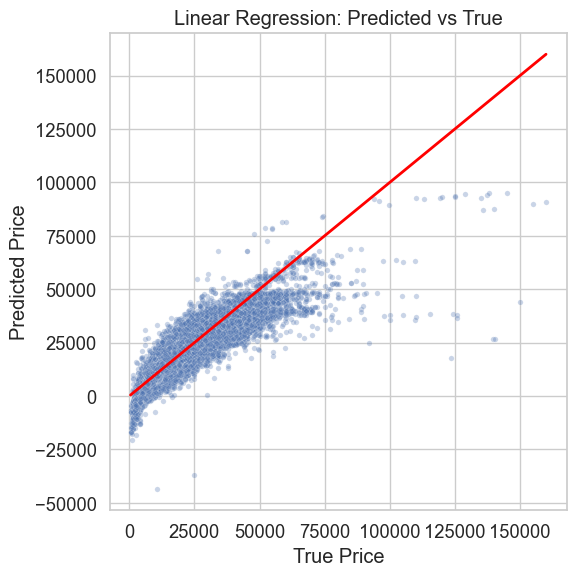

In [5]:
plot_pred_vs_true(linreg_final, "Linear Regression")

Deviations from the diagonal line show systematic bias, specially under-predictions. Low-priced cars tend to be well-ish predicted, while **higher-priced cars are increasingly under-predicted**. The spread grows with price, indicating **heteroskedasticity and limited linear fit** at the most expensive cars.

An important takeaway from this plot is that negative values are being predicted, which does not make sense.

#### 4.4.2. Residuals vs Predicted (heteroscedasticity check)

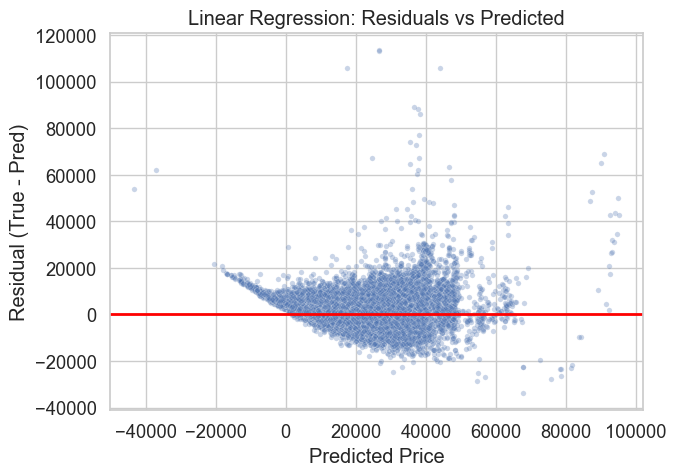

In [6]:
plot_residuals(linreg_final, "Linear Regression")

Residuals are not randomly scattered: variance increases with predicted price, confirming heteroskedasticity. This structured pattern indicates that **linearity assumptions are violated** and that the model struggles with nonlinear price dynamics.

#### 4.4.3. Residual distribution

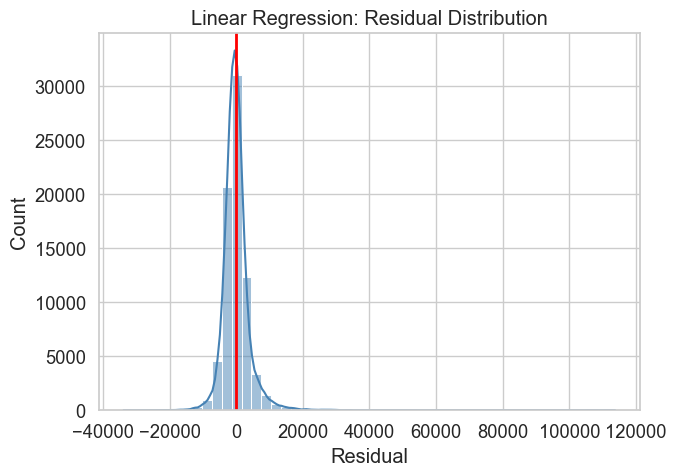

In [7]:
plot_residual_distribution(linreg_final, "Linear Regression")

Residuals form a roughly centered distribution but with heavy tails, showing **large occasional errors**. The red zero-line highlights that although the mean residual is near zero, variance is high, especially on the positive side. This reflects **inconsistent accuracy** across different price ranges.

#### 4.4.4. Permutation Importance

/var/folders/ts/9fy52qg56jz05nxpdkmswkzw0000gr/T/ipykernel_29804/2081930191.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=imp_df, palette="magma")


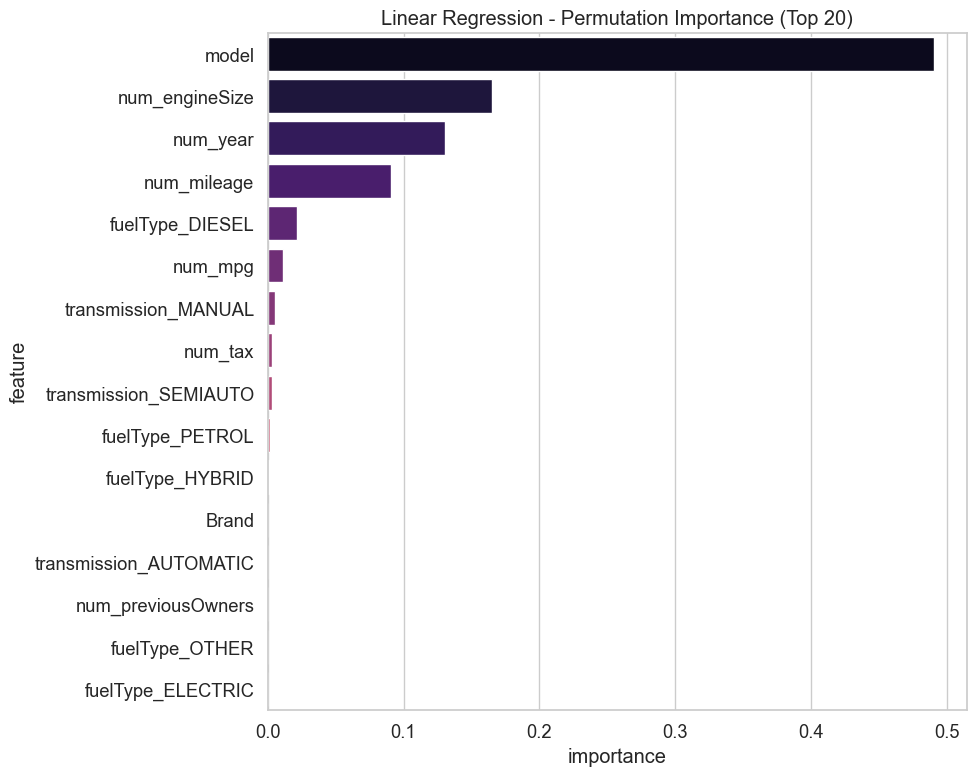

In [8]:
plot_permutation_importance(linreg_final, "Linear Regression")

**`Model` identity dominates prediction power**, followed by `engine size`, `year`, and `mileage`. `Fuel type` and `transmission` contribute modestly. `Brand` has low importance because its information is already captured through model. Overall, the model relies heavily on a small group of numeric and categorical predictors.

#### 4.4.5. SHAP


SHAP for Linear Regression (sample size = 2000)


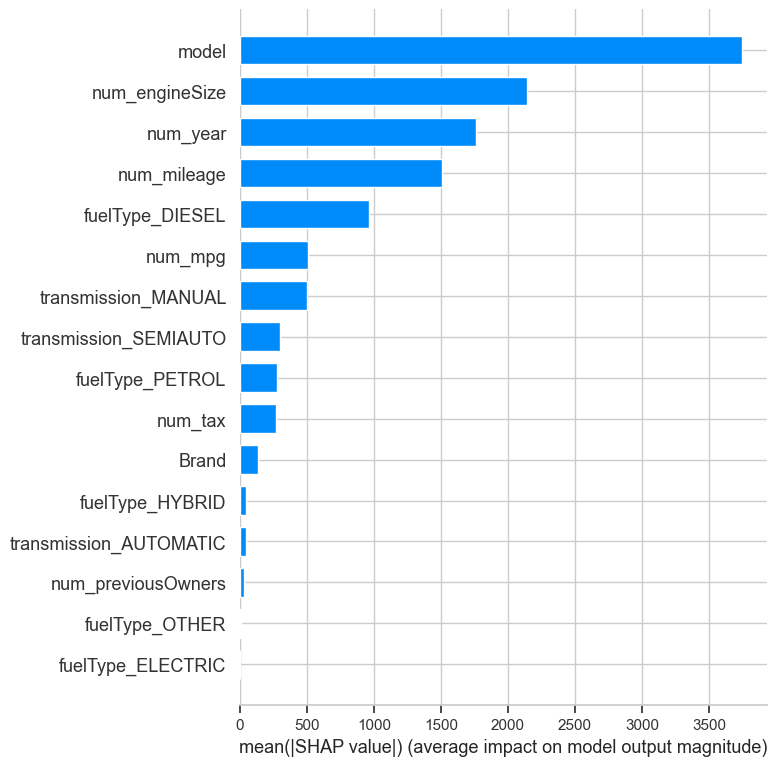

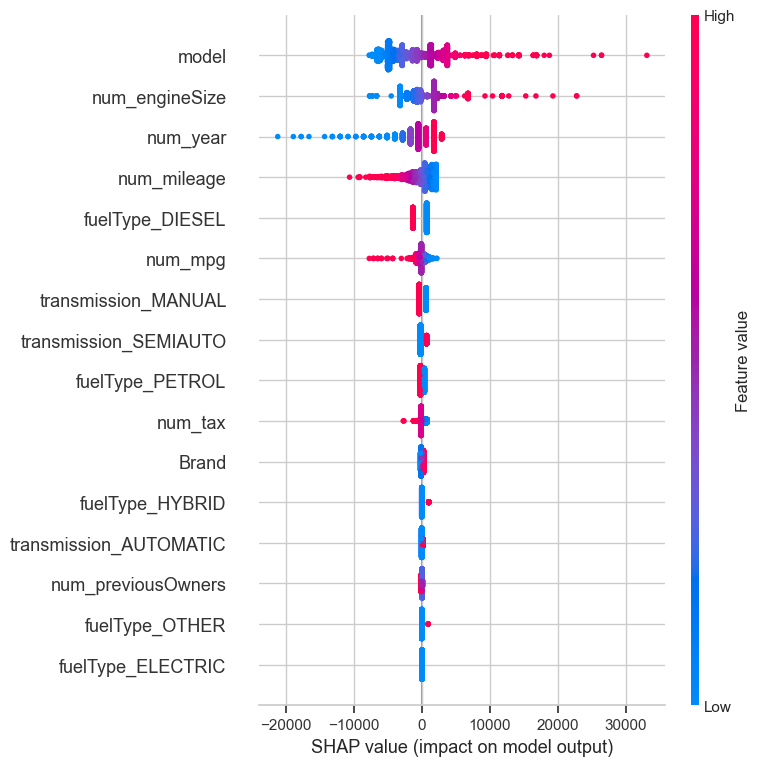

In [9]:
X_shap = X_full_final.copy()
X_shap = X_shap.astype(float)  # converts bool to 0/1 and ensures consistent dtype

apply_shap(linreg_final, X_shap, "Linear Regression")

- **Barplot:**<br>
SHAP confirms the same ranking: `model` is the strongest driver of prediction, with `engine size`, `year`, and `mileage` next. Diesel fuel type consistently increases predicted price, while `mpg` and `tax` have smaller but meaningful contributions. 

- **Beewarm:**<br>
Each top feature shows clear directional effects: **newer cars, larger engines, and lower mileage push predictions upward**, while older cars and high mileage lower them. Feature impacts are asymmetric, especially for `model` and `engine size`. Most low-ranked features show tightly centered SHAP values, confirming minimal effect.

## 5. Ridge Regression (L2 Regularization)

### 5.1. Model Introduction

Ridge Regression extends the baseline model by applying an L2 penalty to shrink coefficients toward zero.

This stabilizes the solution when predictors are correlated and reduces overfitting by preventing large, unstable weights. Ridge maintains all features in the model, but moderates their influence, providing a more robust estimate when the data exhibits multicollinearity or high variance.

It allows us to assess whether controlled shrinkage improves generalization without compromising interpretability.

### 5.2. Hyperparameter Search (K-Fold)

In [12]:
valid_transmissions = ["MANUAL", "AUTOMATIC", "SEMIAUTO"]
valid_fueltypes    = ["PETROL", "DIESEL", "HYBRID"]

# KFold config
N_SPLITS = 8
RANDOM_STATE = 42

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Hyperparameter space for Ridge
ridge_param_distributions = {
    #"alpha": np.logspace(-3, 3, 40)  # 1e-3 to 1e3
    "alpha": np.logspace(-5, 1, 200)  # testing lower alphas since standard linear regression performed better than ridge with higher alphas
}

N_RANDOM_CONFIGS_RIDGE = 40

ridge_sampler = ParameterSampler(
    ridge_param_distributions,
    n_iter=N_RANDOM_CONFIGS_RIDGE,
    random_state=RANDOM_STATE
)

ridge_search_results = []

# Best configs
ridge_best_rmse = np.inf
ridge_best_config_rmse = None

ridge_best_mae = np.inf
ridge_best_config_mae = None

ridge_best_combo = np.inf
ridge_best_config_combo = None

ridge_log_path = "ridge_random_search_log.txt"

with open(ridge_log_path, "w", encoding="utf-8") as log_file:

    def log_ridge(msg: str):
        log_file.write(datetime.now().strftime("[%Y-%m-%d %H:%M:%S] ") + msg + "\n")
        log_file.flush()

    log_ridge("# =============================")
    log_ridge("# START OF RANDOM SEARCH Ridge")
    log_ridge("# =============================")
    log_ridge(f"N_SPLITS = {N_SPLITS}, N_RANDOM_CONFIGS = {N_RANDOM_CONFIGS_RIDGE}")
    log_ridge(f"param_distributions = {ridge_param_distributions}")

    for config_id, params in enumerate(ridge_sampler, start=1):
        log_ridge("")
        log_ridge(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS_RIDGE} ########")
        log_ridge(f"Parameters: {params}")

        fold_rmses_val = []
        fold_maes_val  = []
        fold_r2s_val   = []
        fold_bias_val  = []

        fold_rmses_tr = []
        fold_maes_tr  = []
        fold_r2s_tr   = []
        fold_bias_tr  = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            log_ridge("")
            log_ridge(f"[CONFIG {config_id}] ==== FOLD {fold}/{N_SPLITS} ====")

            # 1) split
            X_train = X.iloc[train_idx].copy()
            X_val   = X.iloc[val_idx].copy()
            y_train = y.iloc[train_idx].copy()
            y_val   = y.iloc[val_idx].copy()

            log_ridge(f"[C{config_id}|F{fold}] X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")
            log_ridge(f"[C{config_id}|F{fold}] y_train shape: {y_train.shape}, y_val shape: {y_val.shape}")

            # NaNs before numeric imputation
            log_ridge(f"[C{config_id}|F{fold}] NaNs before numeric imputation (num features):")
            log_ridge(str(X_train[numeric_features].isna().sum()))

            log_ridge(f"[C{config_id}|F{fold}] NaNs before (categoricals):")
            log_ridge(str(X_train[categorical_features].isna().sum()))

            unknown_counts_before = (X_train[categorical_features] == "UNKNOWN").sum()
            log_ridge(f"[C{config_id}|F{fold}] 'UNKNOWN' before (categoricals):")
            log_ridge(str(unknown_counts_before))

            # 2) NUMERIC PREPROCESSING
            year_state = fit_year_median(
                X_train,
                year_col="year",
                model_col="model"
            )
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(
                X_train,
                mileage_col="mileage",
                do_abs=True
            )
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(
                X_train,
                engine_col="engineSize"
            )
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            tax_state = fit_tax_imputer(
                X_train,
                tax_col="tax",
                do_abs=True
            )
            X_train = transform_tax_imputer(X_train, state=tax_state)
            X_val   = transform_tax_imputer(X_val,   state=tax_state)

            mpg_state = fit_mpg_imputer(
                X_train,
                mpg_col="mpg",
                do_abs=True
            )
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            owners_state = fit_previous_owners_imputer(
                X_train,
                owners_col="previousOwners",
                year_col="year",
                mileage_col="mileage"
            )
            X_train = transform_previous_owners_imputer(X_train, state=owners_state)
            X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

            log_ridge(f"[C{config_id}|F{fold}] After numeric imputation: X_train shape = {X_train.shape}, X_val shape = {X_val.shape}")
            log_ridge(f"[C{config_id}|F{fold}] NaNs after numeric imputation (num features):")
            log_ridge(str(X_train[numeric_features].isna().sum()))

            # 3) CATEGORICAL RESOLVERS
            brand_state = fit_ambiguous_brand_resolver(
                train_df=X_train,
                valid_brands=valid_brands,
                brand_col="Brand",
                model_col="model",
                year_col="year",
            )
            X_train, _, brand_still_invalid_train = transform_ambiguous_brands(X_train, brand_state)
            X_val,   _, brand_still_invalid_val   = transform_ambiguous_brands(X_val,   brand_state)
            log_ridge(f"[C{config_id}|F{fold}] After solving Brand - still invalid (train): {len(brand_still_invalid_train)}")

            model_state = fit_invalid_model_resolver(
                train_df=X_train,
                valid_models_by_brand=valid_models_by_brand,
                brand_col="Brand",
                model_col="model",
                year_col="year",
                fuel_col="fuelType",
                mpg_col="mpg",
            )
            X_train, _, model_still_invalid_train = transform_invalid_models(X_train, model_state)
            X_val,   _, model_still_invalid_val   = transform_invalid_models(X_val,   model_state)
            log_ridge(f"[C{config_id}|F{fold}] After solving model - still invalid (train): {len(model_still_invalid_train)}")

            transm_state = fit_transmission_resolver(
                train_df=X_train,
                valid_transmissions=valid_transmissions,
                transm_col="transmission",
                brand_col="Brand",
                model_col="model",
                fuel_col="fuelType",
            )
            X_train, _, transm_still_invalid_train = transform_transmission_resolver(X_train, transm_state)
            X_val,   _, transm_still_invalid_val   = transform_transmission_resolver(X_val,   transm_state)
            log_ridge(f"[C{config_id}|F{fold}] After solving transmission - distinct (train): " +
                      str(sorted(X_train["transmission"].astype(str).str.upper().unique())))

            fuel_state = fit_fueltype_resolver(
                train_df=X_train,
                valid_fueltypes=valid_fueltypes,
                fuel_col="fuelType",
                brand_col="Brand",
                model_col="model",
                transm_col="transmission",
            )
            X_train, _, fuel_still_invalid_train = transform_fueltype_resolver(X_train, fuel_state)
            X_val,   _, fuel_still_invalid_val   = transform_fueltype_resolver(X_val,   fuel_state)
            log_ridge(f"[C{config_id}|F{fold}] After solving fuelType - distinct (train): " +
                      str(sorted(X_train["fuelType"].astype(str).str.upper().unique())))

            # 4) CATEGORICAL ENCODING
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            log_ridge(f"[C{config_id}|F{fold}] high_card_features = {high_card_features}")
            log_ridge(f"[C{config_id}|F{fold}] low_card_features  = {low_card_features}")

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            log_ridge(f"[C{config_id}|F{fold}] X_train_cat shape: {X_train_cat.shape}")
            log_ridge(f"[C{config_id}|F{fold}] X_val_cat   shape: {X_val_cat.shape}")

            # 5) NUMERIC SCALING
            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train[numeric_features])
            X_val_num   = scaler.transform(X_val[numeric_features])

            X_train_num_df = pd.DataFrame(
                X_train_num,
                index=X_train.index,
                columns=[f"num_{col}" for col in numeric_features]
            )
            X_val_num_df = pd.DataFrame(
                X_val_num,
                index=X_val.index,
                columns=[f"num_{col}" for col in numeric_features]
            )

            log_ridge(f"[C{config_id}|F{fold}] X_train_num_df shape: {X_train_num_df.shape}")
            log_ridge(f"[C{config_id}|F{fold}] X_val_num_df   shape: {X_val_num_df.shape}")

            # 6) FINAL MATRIX
            X_train_final = pd.concat([X_train_num_df, X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val_num_df,   X_val_cat],   axis=1)

            log_ridge(f"[C{config_id}|F{fold}] X_train_final shape: {X_train_final.shape}")
            log_ridge(f"[C{config_id}|F{fold}] X_val_final   shape: {X_val_final.shape}")

            # 7) RIDGE MODEL
            ridge = Ridge(
                alpha=params["alpha"],
                fit_intercept=True
            )

            log_ridge(f"[C{config_id}|F{fold}] Training Ridge...")
            ridge.fit(X_train_final, y_train)

            y_pred_train = ridge.predict(X_train_final)
            y_pred_val   = ridge.predict(X_val_final)

            # 8) METRICS
            mse_val  = mean_squared_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mse_val)
            mae_val  = mean_absolute_error(y_val, y_pred_val)
            r2_val   = r2_score(y_val, y_pred_val)
            bias_val = float(np.mean(y_pred_val - y_val))

            mse_tr  = mean_squared_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mse_tr)
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            r2_tr   = r2_score(y_train, y_pred_train)
            bias_tr = float(np.mean(y_pred_train - y_train))

            log_ridge(f"[C{config_id}|F{fold}] TRAIN -> RMSE: {rmse_tr:.2f} | MAE: {mae_tr:.2f} | R2: {r2_tr:.4f} | Bias(pred-true): {bias_tr:.2f}")
            log_ridge(f"[C{config_id}|F{fold}] VAL   -> RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f} | R2: {r2_val:.4f} | Bias(pred-true): {bias_val:.2f}")

            fold_rmses_tr.append(rmse_tr)
            fold_maes_tr.append(mae_tr)
            fold_r2s_tr.append(r2_tr)
            fold_bias_tr.append(bias_tr)

            fold_rmses_val.append(rmse_val)
            fold_maes_val.append(mae_val)
            fold_r2s_val.append(r2_val)
            fold_bias_val.append(bias_val)

        # mean over folds
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_rmse_tr = np.mean(fold_rmses_tr)
        mean_mae_tr  = np.mean(fold_maes_tr)
        mean_r2_tr   = np.mean(fold_r2s_tr)
        mean_bias_tr = np.mean(fold_bias_tr)

        combo_score = 0.5 * mean_rmse_val + 0.5 * mean_mae_val

        log_ridge("")
        log_ridge(f"Config {config_id} - Avg TRAIN RMSE: {mean_rmse_tr:.2f} | MAE: {mean_mae_tr:.2f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.2f}")
        log_ridge(f"Config {config_id} - Avg VAL   RMSE: {mean_rmse_val:.2f} | MAE: {mean_mae_val:.2f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.2f}")
        log_ridge(f"Config {config_id} - Combined score (0.5*RMSE + 0.5*MAE) [VAL]: {combo_score:.2f}")

        ridge_search_results.append({
            "config_id": config_id,
            **params,
            "rmse_train_mean": mean_rmse_tr,
            "mae_train_mean": mean_mae_tr,
            "r2_train_mean": mean_r2_tr,
            "bias_train_mean": mean_bias_tr,
            "rmse_mean": mean_rmse_val,
            "mae_mean": mean_mae_val,
            "r2_mean": mean_r2_val,
            "bias_mean": mean_bias_val,
            "combo_score": combo_score,
        })

        # best by RMSE
        if mean_rmse_val < ridge_best_rmse:
            ridge_best_rmse = mean_rmse_val
            ridge_best_config_rmse = {**params}
            log_ridge(f"[NEW BEST RMSE] Config {config_id} with avg RMSE (VAL) = {ridge_best_rmse:.2f}")

        # best by MAE
        if mean_mae_val < ridge_best_mae:
            ridge_best_mae = mean_mae_val
            ridge_best_config_mae = {**params}
            log_ridge(f"[NEW BEST MAE] Config {config_id} with avg MAE (VAL) = {ridge_best_mae:.2f}")

        # best by combo
        if combo_score < ridge_best_combo:
            ridge_best_combo = combo_score
            ridge_best_config_combo = {**params}
            log_ridge(f"[NEW BEST COMBINED] Config {config_id} with score = {ridge_best_combo:.2f}")

    log_ridge("")
    log_ridge("# =============================")
    log_ridge("# END OF RANDOM SEARCH Ridge")
    log_ridge("# =============================")
    log_ridge(f"Best configuration (min RMSE VAL): {ridge_best_config_rmse}")
    log_ridge(f"Best average RMSE (VAL): {ridge_best_rmse:.2f}")
    log_ridge(f"Best configuration (min MAE VAL): {ridge_best_config_mae}")
    log_ridge(f"Best average MAE  (VAL): {ridge_best_mae:.2f}")
    log_ridge(f"Best configuration (combined score VAL): {ridge_best_config_combo}")
    log_ridge(f"Best combined score (VAL): {ridge_best_combo:.2f}")

ridge_results_df = pd.DataFrame(ridge_search_results)
ridge_results_df_sorted = ridge_results_df.sort_values(by="mae_mean", ascending=True)

display(ridge_results_df_sorted.head(10))

print("\nBest configuration found (min RMSE VAL):")
print(ridge_best_config_rmse)
print("Best average RMSE (VAL):", ridge_best_rmse)

print("\nBest configuration found (min MAE VAL):")
print(ridge_best_config_mae)
print("Best average MAE (VAL):", ridge_best_mae)

print("\nBest configuration found (min 0.5*RMSE + 0.5*MAE):")
print(ridge_best_config_combo)
print("Best combined score (VAL):", ridge_best_combo)

ridge_results_df_sorted.to_csv("ridge_random_search_results.csv", index=False)
print(f"\nDetailed logs in: {ridge_log_path}")

/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.08495e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.11017e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.12825e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.18995e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/e

,config_id,alpha,rmse_train_mean,mae_train_mean,r2_train_mean,bias_train_mean,rmse_mean,mae_mean,r2_mean,bias_mean,combo_score
14,15,4.055461,4157.772338,2647.171500,0.817657,-9.649959e-13,4183.257624,2653.484398,0.815357,-0.056326,3418.371011
11,12,3.072113,4157.771748,2647.184785,0.817657,-1.296291e-12,4183.261106,2653.501185,0.815356,-0.056352,3418.381146
15,16,2.171118,4157.771199,2647.197169,0.817657,5.332480e-14,4183.265512,2653.517804,0.815356,-0.056278,3418.391658
8,9,1.762914,4157.770954,2647.202865,0.817657,-3.165984e-13,4183.268066,2653.525886,0.815356,-0.056192,3418.396976
7,8,1.335452,4157.770709,2647.208905,0.817657,3.522772e-13,4183.271256,2653.534844,0.815355,-0.056045,3418.403050
12,13,0.943788,4157.770505,2647.214532,0.817657,-6.649733e-13,4183.274778,2653.543614,0.815355,-0.055841,3418.409196
38,39,0.880488,4157.770475,2647.215451,0.817657,-3.309946e-13,4183.275412,2653.545091,0.815355,-0.055800,3418.410252
3,4,0.580523,4157.770350,2647.219842,0.817657,-5.265196e-13,4183.278716,2653.552380,0.815355,-0.055568,3418.415548
17,18,0.382749,4157.770286,2647.222776,0.817657,-1.535192e-13,4183.281204,2653.557479,0.815355,-0.055374,3418.419342
34,35,0.333129,4157.770273,2647.223518,0.817657,-8.063850e-13,4183.281873,2653.558797,0.815355,-0.055319,3418.420335



Best configuration found (min RMSE VAL):
{'alpha': np.float64(4.0554607358408274)}
Best average RMSE (VAL): 4183.257624220869

Best configuration found (min MAE VAL):
{'alpha': np.float64(4.0554607358408274)}
Best average MAE (VAL): 2653.484397534474

Best configuration found (min 0.5*RMSE + 0.5*MAE):
{'alpha': np.float64(4.0554607358408274)}
Best combined score (VAL): 3418.3710108776713

Detailed logs in: ridge_random_search_log.txt


### 5.3 Final Model and Kaggle Predictions

In [13]:
# Choose final hyperparameters from Ridge search
final_config_ridge = ridge_best_config_rmse
#final_config_ridge = {
#    "alpha": ridge_best_config_rmse["alpha"]  
#}
print("Final Ridge config used for train:", final_config_ridge)

print("Preparing final Ridge Regression training...")

# 1) PREPARE FULL TRAIN FEATURES
X_full = X.copy()
y_full = y.copy()

# a) STRING NORMALIZATION 
cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]

for col in cols_to_normalize:
    if col in X_full.columns:
        X_full[col] = X_full[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

# Define feature sets
high_card_features = ["Brand", "model"] 
low_card_features  = [c for c in categorical_features if c not in high_card_features]

# 2) NUMERIC PRE PROCESSING - FULL TRAIN (FIT & TRANSFORM)
# Year
year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, state=year_state)

# Mileage
mileage_state = fit_mileage_imputer(X_full, mileage_col="mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, state=mileage_state)

# Engine Size
engine_state = fit_engine_size_imputer(X_full, engine_col="engineSize")
X_full = transform_engine_size_imputer(X_full, state=engine_state)

# Tax
tax_state = fit_tax_imputer(X_full, tax_col="tax", do_abs=True)
X_full = transform_tax_imputer(X_full, state=tax_state)

# MPG
mpg_state = fit_mpg_imputer(X_full, mpg_col="mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, state=mpg_state)

# Paint Quality 
# paint_state = fit_paint_quality_imputer(X_full, paint_col="paintQuality%")
# X_full = transform_paint_quality_imputer(X_full, state=paint_state)

# Previous Owners
owners_state = fit_previous_owners_imputer(
    X_full, owners_col="previousOwners", year_col="year", mileage_col="mileage"
)
X_full = transform_previous_owners_imputer(X_full, state=owners_state)

# 3) CATEGORICAL RESOLVERS - FULL TRAIN (FIT & TRANSFORM)
# Brand
brand_state = fit_ambiguous_brand_resolver(
    train_df=X_full, valid_brands=valid_brands, 
    brand_col="Brand", model_col="model", year_col="year"
)
X_full, _, brand_still_invalid_full = transform_ambiguous_brands(X_full, brand_state)
print(f"Train full - Invalid Brands remaining: {len(brand_still_invalid_full)}")

# Model
model_state = fit_invalid_model_resolver(
    train_df=X_full, valid_models_by_brand=valid_models_by_brand,
    brand_col="Brand", model_col="model", year_col="year", 
    fuel_col="fuelType", mpg_col="mpg"
)
X_full, _, model_still_invalid_full = transform_invalid_models(X_full, model_state)
print(f"Train full - Invalid Models remaining: {len(model_still_invalid_full)}")

# Transmission
transm_state = fit_transmission_resolver(
    train_df=X_full, valid_transmissions=valid_transmissions,
    transm_col="transmission", brand_col="Brand", 
    model_col="model", fuel_col="fuelType"
)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

# Fuel Type
fuel_state = fit_fueltype_resolver(
    train_df=X_full, valid_fueltypes=valid_fueltypes,
    fuel_col="fuelType", brand_col="Brand", 
    model_col="model", transm_col="transmission"
)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)

# 4) CATEGORICAL ENCODING - FULL TRAIN (FIT & TRANSFORM)
# Target Encoding
te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full)
X_full_high = te.transform(X_full[high_card_features])

# One-Hot Encoding
ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)
print("X_full_cat shape:", X_full_cat.shape)

# 5) NUMERIC SCALING - FULL TRAIN (FIT & TRANSFORM)
scaler = StandardScaler()
X_full_num = scaler.fit_transform(X_full[numeric_features])

X_full_num_df = pd.DataFrame(
    X_full_num,
    index=X_full.index,
    columns=[f"num_{col}" for col in numeric_features]
)
print("X_full_num_df shape:", X_full_num_df.shape)

# 6) FINAL MATRIX - FULL TRAIN
X_full_final = pd.concat([X_full_num_df, X_full_cat], axis=1)
print("X_full_final shape:", X_full_final.shape)

# 7) TRAIN FINAL RIDGE REGRESSION MODEL
ridge_final = Ridge(
    alpha=final_config_ridge["alpha"],
    fit_intercept=True
)

print("Training final Ridge Regression model on full data...")
ridge_final.fit(X_full_final, y_full)
print("Done.")

# 8) PREPARE TEST FEATURES
test_df = pd.read_csv("../../project_data/test.csv")

# a) STRING NORMALIZATION (same logic as train)
for col in cols_to_normalize:
    if col in test_df.columns:
        test_df[col] = test_df[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

X_test = test_df[numeric_features + categorical_features].copy()

# b) NUMERIC PREPROCESSING - TEST (TRANSFORM ONLY)
X_test = transform_year_with_model_median(X_test, state=year_state)
X_test = transform_mileage_imputer(X_test, state=mileage_state)
X_test = transform_engine_size_imputer(X_test, state=engine_state)
X_test = transform_tax_imputer(X_test, state=tax_state)
X_test = transform_mpg_imputer(X_test, state=mpg_state)
# X_test = transform_paint_quality_imputer(X_test, state=paint_state)
X_test = transform_previous_owners_imputer(X_test, state=owners_state)

# c) CATEGORICAL RESOLVERS - TEST (TRANSFORM ONLY)
X_test, _, _ = transform_ambiguous_brands(X_test, brand_state)
X_test, _, _ = transform_invalid_models(X_test, model_state)
X_test, _, _ = transform_transmission_resolver(X_test, transm_state)
X_test, _, _ = transform_fueltype_resolver(X_test, fuel_state)

# d) ENCODING - TEST (TRANSFORM ONLY)
X_test_high = te.transform(X_test[high_card_features])
X_test_low  = ohe.transform(X_test[low_card_features])
X_test_cat  = pd.concat([X_test_high, X_test_low], axis=1)

# e) SCALING - TEST (TRANSFORM ONLY)
X_test_num = scaler.transform(X_test[numeric_features])
X_test_num_df = pd.DataFrame(
    X_test_num,
    index=X_test.index,
    columns=[f"num_{col}" for col in numeric_features]
)

# 9) FINAL MATRIX & PREDICTION
X_test_final = pd.concat([X_test_num_df, X_test_cat], axis=1)

# Ensure same column order as training
X_test_final = X_test_final[X_full_final.columns]

print("X_test_final shape:", X_test_final.shape)

y_test_pred = ridge_final.predict(X_test_final)

print("Predictions summary (float):")
print(pd.Series(y_test_pred).describe())

# Optional rounding
y_test_pred_round = np.round(y_test_pred).astype(int)

submission = pd.DataFrame({
    "carID": test_df["carID"].astype(int),
    "price": y_test_pred  
})

sub_name = f"ridge_regression_final_submission_alpha{final_config_ridge['alpha']:.4f}.csv"
submission.to_csv(sub_name, index=False)
print(f"Submission file created: {sub_name}")

Final Ridge config used for train: {'alpha': np.float64(4.0554607358408274)}
Preparing final Ridge Regression training...
Train full - Invalid Brands remaining: 0
Train full - Invalid Models remaining: 1
X_full_cat shape: (75973, 10)
X_full_num_df shape: (75973, 6)
X_full_final shape: (75973, 16)
Training final Ridge Regression model on full data...
Done.
X_test_final shape: (32567, 16)
Predictions summary (float):
count    32567.000000
mean     16897.964279
std       8754.627296
min     -19433.780492
25%      10847.979789
50%      15467.386974
75%      22288.709810
max      95042.450777
dtype: float64
Submission file created: ridge_regression_final_submission_alpha4.0555.csv


### 5.4. Diagnostic Visualizations

#### 5.4.1. Predicted vs true

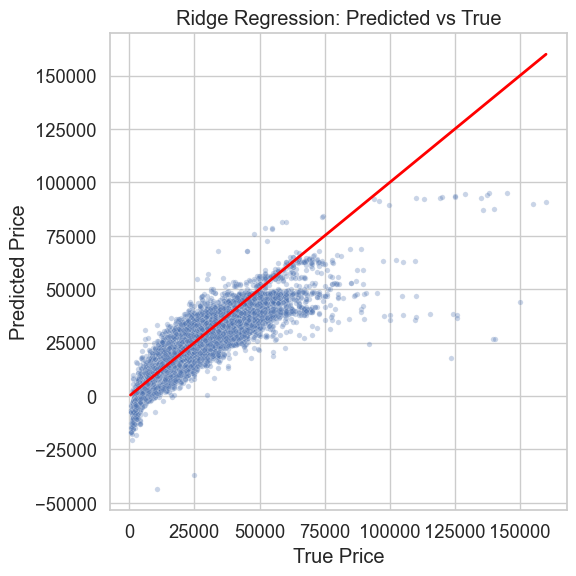

In [14]:
plot_pred_vs_true(ridge_final, "Ridge Regression")

#### 5.4.2. Residuals vs Predicted (heteroscedasticity check)

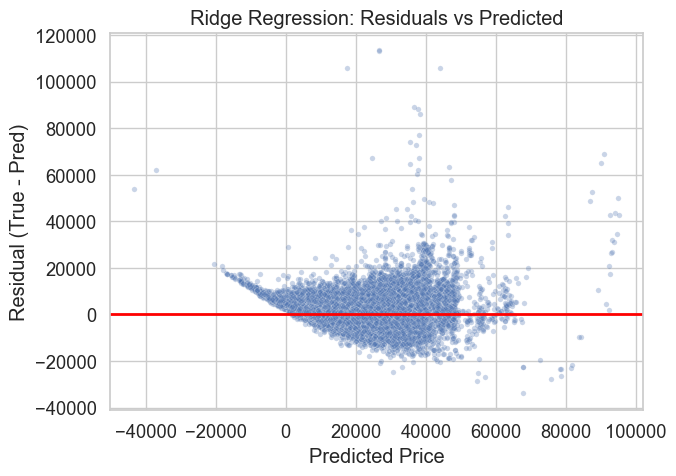

In [15]:
plot_residuals(ridge_final, "Ridge Regression")

#### 5.4.3. Residual distribution

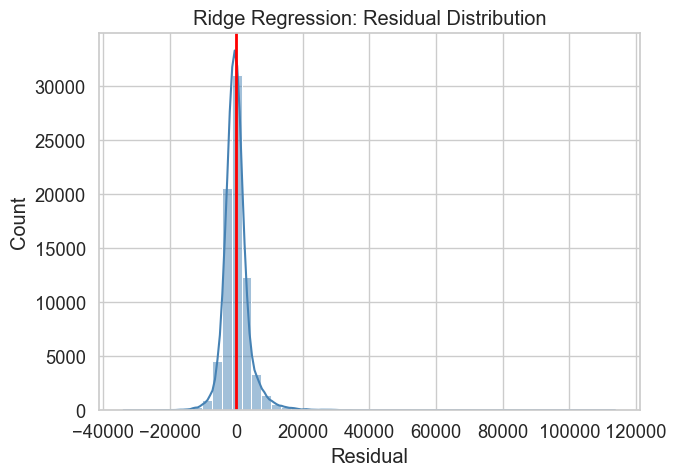

In [16]:
plot_residual_distribution(ridge_final, "Ridge Regression")

#### 5.4.4. Permutation Importance

/var/folders/ts/9fy52qg56jz05nxpdkmswkzw0000gr/T/ipykernel_29804/2081930191.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=imp_df, palette="magma")


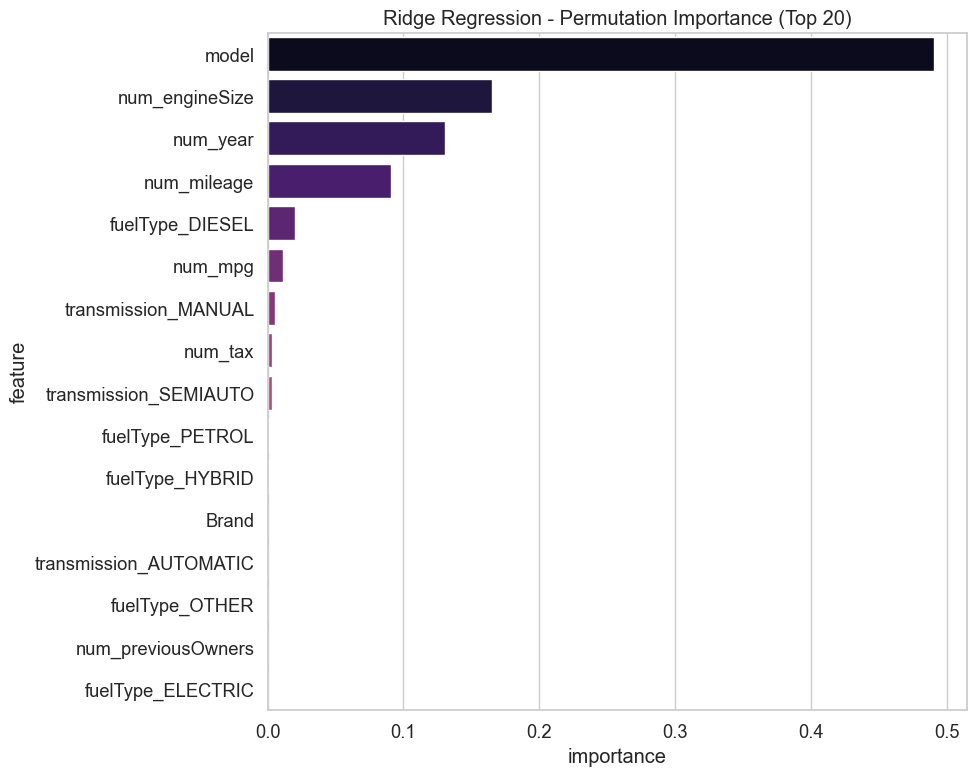

In [17]:
plot_permutation_importance(ridge_final, "Ridge Regression")

#### 5.4.5. SHAP


SHAP for Ridge Regression (sample size = 2000)


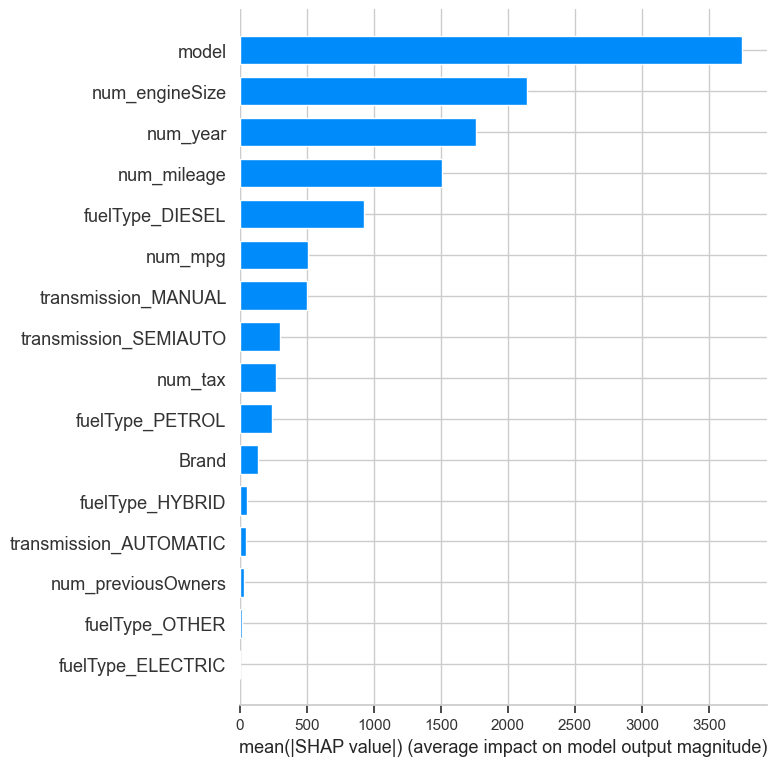

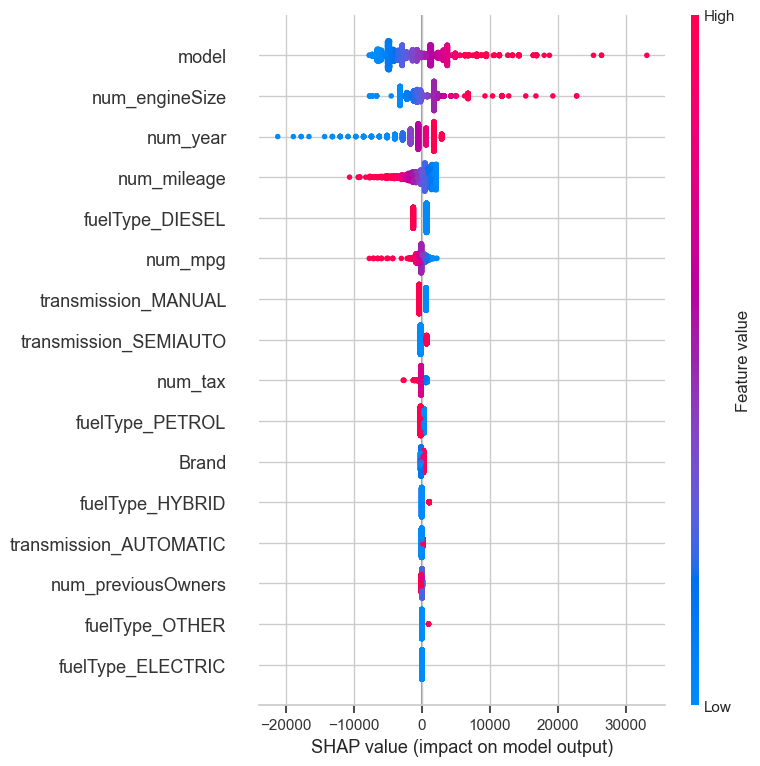

In [18]:
X_shap = X_full_final.copy()
X_shap = X_shap.astype(float)  # converts bool to 0/1 and ensures consistent dtype

apply_shap(ridge_final, X_shap, "Ridge Regression")

## 6. Lasso Regression (L1 Regularization)

### 6.1. Model Introduction

Lasso introduces L1 regularization, which can shrink some coefficients exactly to zero. This property enables implicit feature selection, making Lasso useful when the dataset may contain noisy or weakly informative predictors. 

Compared with Ridge, Lasso produces a more compact and interpretable model, allowing us to evaluate whether sparsity (keeping only the strongest signals) leads to better performance on unseen data.

It is a direct test of whether a simpler representation of the data generalizes better than the full linear model.

### 6.2. Hyperparameter Search (K-Fold)

In [19]:
valid_transmissions = ["MANUAL", "AUTOMATIC", "SEMIAUTO"]
valid_fueltypes    = ["PETROL", "DIESEL", "HYBRID"]

# KFold config
N_SPLITS = 8
RANDOM_STATE = 42

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

lasso_param_distributions = {
    #"alpha": np.logspace(-3, 1, 40)  # 1e-3 to 10
    "alpha": np.logspace(-5, 1, 200)  # testing lower alphas since standard linear regression performed better than lasso with higher alphas
}

N_RANDOM_CONFIGS_LASSO = 50

lasso_sampler = ParameterSampler(
    lasso_param_distributions,
    n_iter=N_RANDOM_CONFIGS_LASSO,
    random_state=RANDOM_STATE
)

lasso_search_results = []

lasso_best_rmse = np.inf
lasso_best_config_rmse = None

lasso_best_mae = np.inf
lasso_best_config_mae = None

lasso_best_combo = np.inf
lasso_best_config_combo = None

lasso_log_path = "lasso_random_search_log.txt"

with open(lasso_log_path, "w", encoding="utf-8") as log_file:

    def log_lasso(msg: str):
        log_file.write(datetime.now().strftime("[%Y-%m-%d %H:%M:%S] ") + msg + "\n")
        log_file.flush()

    log_lasso("# =============================")
    log_lasso("# START OF RANDOM SEARCH Lasso")
    log_lasso("# =============================")
    log_lasso(f"N_SPLITS = {N_SPLITS}, N_RANDOM_CONFIGS = {N_RANDOM_CONFIGS_LASSO}")
    log_lasso(f"param_distributions = {lasso_param_distributions}")

    for config_id, params in enumerate(lasso_sampler, start=1):
        log_lasso("")
        log_lasso(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS_LASSO} ########")
        log_lasso(f"Parameters: {params}")

        fold_rmses_val = []
        fold_maes_val  = []
        fold_r2s_val   = []
        fold_bias_val  = []

        fold_rmses_tr = []
        fold_maes_tr  = []
        fold_r2s_tr   = []
        fold_bias_tr  = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            log_lasso("")
            log_lasso(f"[CONFIG {config_id}] ==== FOLD {fold}/{N_SPLITS} ====")

            X_train = X.iloc[train_idx].copy()
            X_val   = X.iloc[val_idx].copy()
            y_train = y.iloc[train_idx].copy()
            y_val   = y.iloc[val_idx].copy()

            log_lasso(f"[C{config_id}|F{fold}] X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")
            log_lasso(f"[C{config_id}|F{fold}] y_train shape: {y_train.shape}, y_val shape: {y_val.shape}")

            # numeric imputers
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            tax_state = fit_tax_imputer(X_train, tax_col="tax", do_abs=True)
            X_train = transform_tax_imputer(X_train, state=tax_state)
            X_val   = transform_tax_imputer(X_val,   state=tax_state)

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            owners_state = fit_previous_owners_imputer(
                X_train, owners_col="previousOwners", year_col="year", mileage_col="mileage"
            )
            X_train = transform_previous_owners_imputer(X_train, state=owners_state)
            X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

            # resolvers
            brand_state = fit_ambiguous_brand_resolver(
                train_df=X_train, valid_brands=valid_brands,
                brand_col="Brand", model_col="model", year_col="year"
            )
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

            model_state = fit_invalid_model_resolver(
                train_df=X_train, valid_models_by_brand=valid_models_by_brand,
                brand_col="Brand", model_col="model", year_col="year",
                fuel_col="fuelType", mpg_col="mpg"
            )
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val,   _, _ = transform_invalid_models(X_val,   model_state)

            transm_state = fit_transmission_resolver(
                train_df=X_train, valid_transmissions=valid_transmissions,
                transm_col="transmission", brand_col="Brand",
                model_col="model", fuel_col="fuelType"
            )
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

            fuel_state = fit_fueltype_resolver(
                train_df=X_train, valid_fueltypes=valid_fueltypes,
                fuel_col="fuelType", brand_col="Brand",
                model_col="model", transm_col="transmission"
            )
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)

            # encoding
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # scaling
            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train[numeric_features])
            X_val_num   = scaler.transform(X_val[numeric_features])

            X_train_num_df = pd.DataFrame(
                X_train_num,
                index=X_train.index,
                columns=[f"num_{col}" for col in numeric_features]
            )
            X_val_num_df = pd.DataFrame(
                X_val_num,
                index=X_val.index,
                columns=[f"num_{col}" for col in numeric_features]
            )

            X_train_final = pd.concat([X_train_num_df, X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val_num_df,   X_val_cat],   axis=1)

            # model
            lasso = Lasso(
                alpha=params["alpha"],
                fit_intercept=True,
                max_iter=10000
            )

            log_lasso(f"[C{config_id}|F{fold}] Training Lasso...")
            lasso.fit(X_train_final, y_train)

            y_pred_train = lasso.predict(X_train_final)
            y_pred_val   = lasso.predict(X_val_final)

            mse_val  = mean_squared_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mse_val)
            mae_val  = mean_absolute_error(y_val, y_pred_val)
            r2_val   = r2_score(y_val, y_pred_val)
            bias_val = float(np.mean(y_pred_val - y_val))

            mse_tr  = mean_squared_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mse_tr)
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            r2_tr   = r2_score(y_train, y_pred_train)
            bias_tr = float(np.mean(y_pred_train - y_train))

            log_lasso(f"[C{config_id}|F{fold}] TRAIN -> RMSE: {rmse_tr:.2f} | MAE: {mae_tr:.2f} | R2: {r2_tr:.4f} | Bias(pred-true): {bias_tr:.2f}")
            log_lasso(f"[C{config_id}|F{fold}] VAL   -> RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f} | R2: {r2_val:.4f} | Bias(pred-true): {bias_val:.2f}")

            fold_rmses_tr.append(rmse_tr)
            fold_maes_tr.append(mae_tr)
            fold_r2s_tr.append(r2_tr)
            fold_bias_tr.append(bias_tr)

            fold_rmses_val.append(rmse_val)
            fold_maes_val.append(mae_val)
            fold_r2s_val.append(r2_val)
            fold_bias_val.append(bias_val)

        # mean over folds
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_rmse_tr = np.mean(fold_rmses_tr)
        mean_mae_tr  = np.mean(fold_maes_tr)
        mean_r2_tr   = np.mean(fold_r2s_tr)
        mean_bias_tr = np.mean(fold_bias_tr)

        combo_score = 0.5 * mean_rmse_val + 0.5 * mean_mae_val

        log_lasso(f"Config {config_id} - Avg TRAIN RMSE: {mean_rmse_tr:.2f} | MAE: {mean_mae_tr:.2f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.2f}")
        log_lasso(f"Config {config_id} - Avg VAL   RMSE: {mean_rmse_val:.2f} | MAE: {mean_mae_val:.2f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.2f}")
        log_lasso(f"Config {config_id} - Combined score (0.5*RMSE + 0.5*MAE) [VAL]: {combo_score:.2f}")

        lasso_search_results.append({
            "config_id": config_id,
            **params,
            "rmse_train_mean": mean_rmse_tr,
            "mae_train_mean": mean_mae_tr,
            "r2_train_mean": mean_r2_tr,
            "bias_train_mean": mean_bias_tr,
            "rmse_mean": mean_rmse_val,
            "mae_mean": mean_mae_val,
            "r2_mean": mean_r2_val,
            "bias_mean": mean_bias_val,
            "combo_score": combo_score,
        })

        if mean_rmse_val < lasso_best_rmse:
            lasso_best_rmse = mean_rmse_val
            lasso_best_config_rmse = {**params}
            log_lasso(f"[NEW BEST RMSE] Config {config_id} with avg RMSE (VAL) = {lasso_best_rmse:.2f}")

        if mean_mae_val < lasso_best_mae:
            lasso_best_mae = mean_mae_val
            lasso_best_config_mae = {**params}
            log_lasso(f"[NEW BEST MAE] Config {config_id} with avg MAE (VAL) = {lasso_best_mae:.2f}")

        if combo_score < lasso_best_combo:
            lasso_best_combo = combo_score
            lasso_best_config_combo = {**params}
            log_lasso(f"[NEW BEST COMBINED] Config {config_id} with score = {lasso_best_combo:.2f}")

    log_lasso("")
    log_lasso("# =============================")
    log_lasso("# END OF RANDOM SEARCH Lasso")
    log_lasso("# =============================")
    log_lasso(f"Best configuration (min RMSE VAL): {lasso_best_config_rmse}")
    log_lasso(f"Best average RMSE (VAL): {lasso_best_rmse:.2f}")
    log_lasso(f"Best configuration (min MAE VAL): {lasso_best_config_mae}")
    log_lasso(f"Best average MAE  (VAL): {lasso_best_mae:.2f}")
    log_lasso(f"Best configuration (combined score VAL): {lasso_best_config_combo}")
    log_lasso(f"Best combined score (VAL): {lasso_best_combo:.2f}")

lasso_results_df = pd.DataFrame(lasso_search_results)
lasso_results_df_sorted = lasso_results_df.sort_values(by="mae_mean", ascending=True)

display(lasso_results_df_sorted.head(10))

print("\nBest configuration found (min RMSE VAL):")
print(lasso_best_config_rmse)
print("Best average RMSE (VAL):", lasso_best_rmse)

print("\nBest configuration found (min MAE VAL):")
print(lasso_best_config_mae)
print("Best average MAE (VAL):", lasso_best_mae)

print("\nBest configuration found (min 0.5*RMSE + 0.5*MAE):")
print(lasso_best_config_combo)
print("Best combined score (VAL):", lasso_best_combo)

lasso_results_df_sorted.to_csv("lasso_random_search_results.csv", index=False)
print(f"\nDetailed logs in: {lasso_log_path}")## 3. Final Model Training and Kaggle Submission Generation

/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.348e+11, tolerance: 6.343e+08
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.341e+11, tolerance: 6.312e+08
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing reg

,config_id,alpha,rmse_train_mean,mae_train_mean,r2_train_mean,bias_train_mean,rmse_mean,mae_mean,r2_mean,bias_mean,combo_score
41,42,8.703591,4158.929594,2643.846017,0.817555,-5.258018e-13,4184.483421,2650.165425,0.815247,-0.043288,3417.324423
45,46,7.575250,4158.793045,2644.264970,0.817567,-3.554011e-13,4184.324146,2650.573996,0.815261,-0.042355,3417.449071
14,15,4.055461,4158.488680,2645.700188,0.817594,-4.864685e-13,4183.949694,2651.994149,0.815295,-0.039643,3417.971922
11,12,3.072113,4158.357344,2646.055008,0.817606,-8.147455e-13,4183.859745,2652.406941,0.815303,-0.054261,3418.133343
15,16,2.171118,4158.089582,2646.256796,0.817629,-4.747824e-13,4183.631398,2652.645406,0.815323,-0.057903,3418.138402
8,9,1.762914,4157.980924,2646.374998,0.817639,-3.974013e-13,4183.514986,2652.756098,0.815334,-0.053084,3418.135542
7,8,1.335452,4157.888720,2646.540397,0.817647,-3.973209e-13,4183.410827,2652.886516,0.815343,-0.060912,3418.148671
12,13,0.943788,4157.829708,2646.717271,0.817652,-2.450861e-13,4183.343577,2653.049412,0.815349,-0.060191,3418.196494
38,39,0.880488,4157.822219,2646.747878,0.817652,-2.284818e-13,4183.335191,2653.078598,0.815350,-0.059915,3418.206895
3,4,0.580523,4157.793149,2646.900261,0.817655,7.990240e-13,4183.299540,2653.226291,0.815353,-0.059032,3418.262915



Best configuration found (min RMSE VAL):
{'alpha': np.float64(0.029331662783900425)}
Best average RMSE (VAL): 4183.261161230614

Best configuration found (min MAE VAL):
{'alpha': np.float64(8.703591361485167)}
Best average MAE (VAL): 2650.165425476597

Best configuration found (min 0.5*RMSE + 0.5*MAE):
{'alpha': np.float64(8.703591361485167)}
Best combined score (VAL): 3417.324423483984

Detailed logs in: lasso_random_search_log.txt


### 6.3. Final Model and Kaggle Predictions

In [20]:
# Choose final hyperparameters 
final_config_lasso = lasso_best_config_rmse
#final_config_lasso = {
#    "alpha": lasso_best_config_rmse["alpha"]
#}
print("Final Lasso config used for train:", final_config_lasso)

print("Preparing final Lasso Regression training...")

# 1) PREPARE FULL TRAIN FEATURES
X_full = X.copy()
y_full = y.copy()

# a) STRING NORMALIZATION
cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]

for col in cols_to_normalize:
    if col in X_full.columns:
        X_full[col] = X_full[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

# Feature sets
high_card_features = ["Brand", "model"] 
low_card_features  = [c for c in categorical_features if c not in high_card_features]

# 2) NUMERIC PRE PROCESSING - FULL TRAIN
year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, state=year_state)

mileage_state = fit_mileage_imputer(X_full, mileage_col="mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, state=mileage_state)

engine_state = fit_engine_size_imputer(X_full, engine_col="engineSize")
X_full = transform_engine_size_imputer(X_full, state=engine_state)

tax_state = fit_tax_imputer(X_full, tax_col="tax", do_abs=True)
X_full = transform_tax_imputer(X_full, state=tax_state)

mpg_state = fit_mpg_imputer(X_full, mpg_col="mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, state=mpg_state)

# paint_state = fit_paint_quality_imputer(X_full, paint_col="paintQuality%")
# X_full = transform_paint_quality_imputer(X_full, state=paint_state)

owners_state = fit_previous_owners_imputer(
    X_full, owners_col="previousOwners", year_col="year", mileage_col="mileage"
)
X_full = transform_previous_owners_imputer(X_full, state=owners_state)

# 3) CATEGORICAL RESOLVERS - FULL TRAIN
brand_state = fit_ambiguous_brand_resolver(
    train_df=X_full, valid_brands=valid_brands, 
    brand_col="Brand", model_col="model", year_col="year"
)
X_full, _, brand_still_invalid_full = transform_ambiguous_brands(X_full, brand_state)
print(f"Train full - Invalid Brands remaining: {len(brand_still_invalid_full)}")

model_state = fit_invalid_model_resolver(
    train_df=X_full, valid_models_by_brand=valid_models_by_brand,
    brand_col="Brand", model_col="model", year_col="year", 
    fuel_col="fuelType", mpg_col="mpg"
)
X_full, _, model_still_invalid_full = transform_invalid_models(X_full, model_state)
print(f"Train full - Invalid Models remaining: {len(model_still_invalid_full)}")

transm_state = fit_transmission_resolver(
    train_df=X_full, valid_transmissions=valid_transmissions,
    transm_col="transmission", brand_col="Brand", 
    model_col="model", fuel_col="fuelType"
)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

fuel_state = fit_fueltype_resolver(
    train_df=X_full, valid_fueltypes=valid_fueltypes,
    fuel_col="fuelType", brand_col="Brand", 
    model_col="model", transm_col="transmission"
)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)

# 4) CATEGORICAL ENCODING - FULL TRAIN
te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full)
X_full_high = te.transform(X_full[high_card_features])

ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)
print("X_full_cat shape:", X_full_cat.shape)

# 5) NUMERIC SCALING - FULL TRAIN
scaler = StandardScaler()
X_full_num = scaler.fit_transform(X_full[numeric_features])

X_full_num_df = pd.DataFrame(
    X_full_num,
    index=X_full.index,
    columns=[f"num_{col}" for col in numeric_features]
)
print("X_full_num_df shape:", X_full_num_df.shape)

# 6) FINAL MATRIX - FULL TRAIN
X_full_final = pd.concat([X_full_num_df, X_full_cat], axis=1)
print("X_full_final shape:", X_full_final.shape)

# 7) TRAIN FINAL LASSO REGRESSION MODEL
lasso_final = Lasso(
    alpha=final_config_lasso["alpha"],
    fit_intercept=True,
    max_iter=10000
)

print("Training final Lasso Regression model on full data...")
lasso_final.fit(X_full_final, y_full)
print("Done.")

# 8) PREPARE TEST FEATURES
test_df = pd.read_csv("../../project_data/test.csv")

for col in cols_to_normalize:
    if col in test_df.columns:
        test_df[col] = test_df[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

X_test = test_df[numeric_features + categorical_features].copy()

# NUMERIC PREPROCESSING - TEST
X_test = transform_year_with_model_median(X_test, state=year_state)
X_test = transform_mileage_imputer(X_test, state=mileage_state)
X_test = transform_engine_size_imputer(X_test, state=engine_state)
X_test = transform_tax_imputer(X_test, state=tax_state)
X_test = transform_mpg_imputer(X_test, state=mpg_state)
# X_test = transform_paint_quality_imputer(X_test, state=paint_state)
X_test = transform_previous_owners_imputer(X_test, state=owners_state)

# CATEGORICAL RESOLVERS - TEST
X_test, _, _ = transform_ambiguous_brands(X_test, brand_state)
X_test, _, _ = transform_invalid_models(X_test, model_state)
X_test, _, _ = transform_transmission_resolver(X_test, transm_state)
X_test, _, _ = transform_fueltype_resolver(X_test, fuel_state)

# ENCODING - TEST
X_test_high = te.transform(X_test[high_card_features])
X_test_low  = ohe.transform(X_test[low_card_features])
X_test_cat  = pd.concat([X_test_high, X_test_low], axis=1)

# SCALING - TEST
X_test_num = scaler.transform(X_test[numeric_features])
X_test_num_df = pd.DataFrame(
    X_test_num,
    index=X_test.index,
    columns=[f"num_{col}" for col in numeric_features]
)

# FINAL MATRIX & PREDICTION
X_test_final = pd.concat([X_test_num_df, X_test_cat], axis=1)
X_test_final = X_test_final[X_full_final.columns]

print("X_test_final shape:", X_test_final.shape)

y_test_pred = lasso_final.predict(X_test_final)

print("Predictions summary (float):")
print(pd.Series(y_test_pred).describe())

y_test_pred_round = np.round(y_test_pred).astype(int)

submission = pd.DataFrame({
    "carID": test_df["carID"].astype(int),
    "price": y_test_pred  
})

sub_name = f"lasso_regression_final_submission_alpha{final_config_lasso['alpha']:.4f}.csv"
submission.to_csv(sub_name, index=False)
print(f"Submission file created: {sub_name}")

Final Lasso config used for train: {'alpha': np.float64(0.029331662783900425)}
Preparing final Lasso Regression training...
Train full - Invalid Brands remaining: 0
Train full - Invalid Models remaining: 1
X_full_cat shape: (75973, 10)
X_full_num_df shape: (75973, 6)
X_full_final shape: (75973, 16)
Training final Lasso Regression model on full data...


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.237e+11, tolerance: 7.203e+08
  model = cd_fast.enet_coordinate_descent(


Done.
X_test_final shape: (32567, 16)
Predictions summary (float):
count    32567.000000
mean     16897.966414
std       8754.745484
min     -19434.435225
25%      10848.000923
50%      15467.214140
75%      22288.636866
max      95042.670455
dtype: float64
Submission file created: lasso_regression_final_submission_alpha0.0293.csv


### 6.4. Diagnostic Visualizations

#### 6.4.1. Predicted vs true

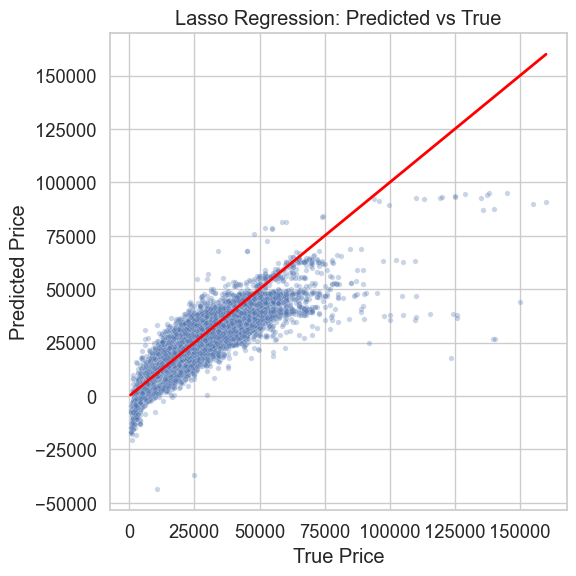

In [21]:
plot_pred_vs_true(lasso_final, "Lasso Regression")

#### 6.4.2. Residuals vs Predicted (heteroscedasticity check)

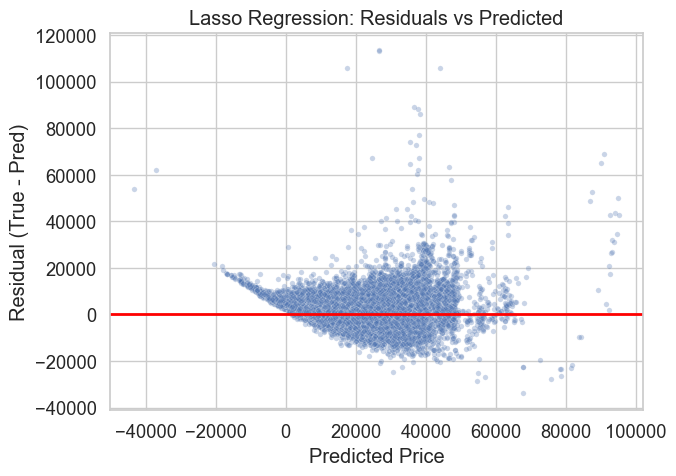

In [22]:
plot_residuals(lasso_final, "Lasso Regression")

#### 6.4.3. Residual distribution

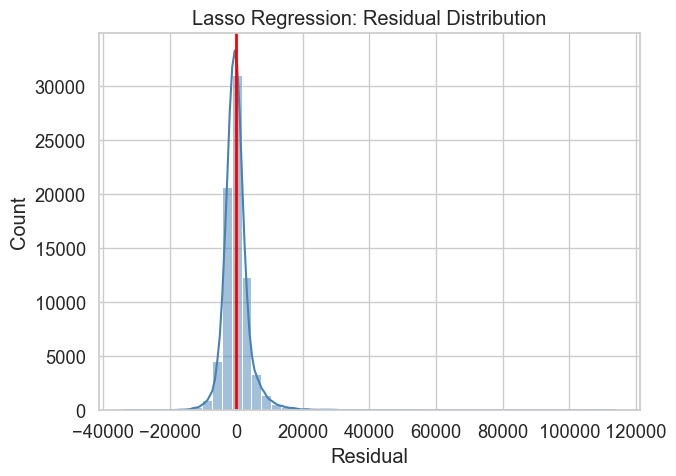

In [23]:
plot_residual_distribution(lasso_final, "Lasso Regression")

#### 6.4.4. Permutation Importance

/var/folders/ts/9fy52qg56jz05nxpdkmswkzw0000gr/T/ipykernel_29804/2081930191.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=imp_df, palette="magma")


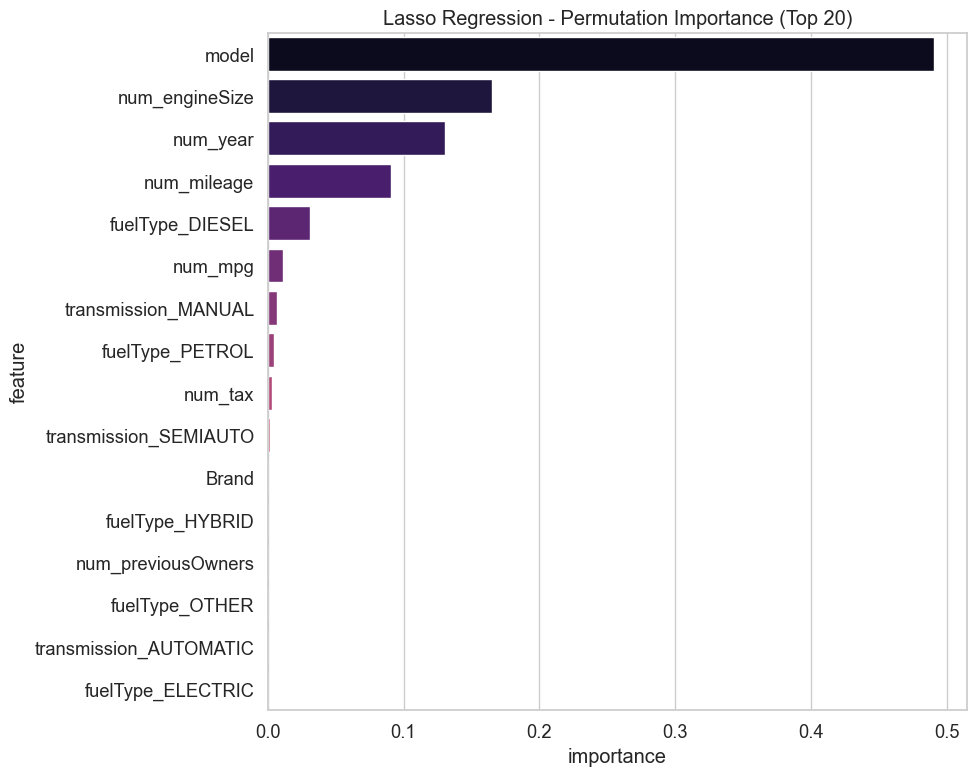

In [24]:
plot_permutation_importance(lasso_final, "Lasso Regression")

#### 6.4.5. SHAP


SHAP for Lasso Regression (sample size = 2000)


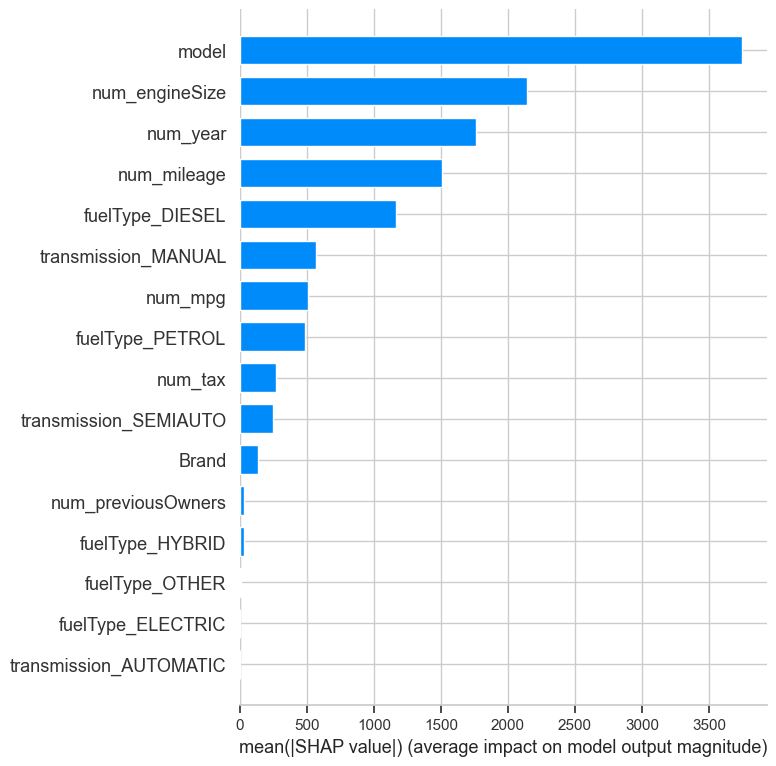

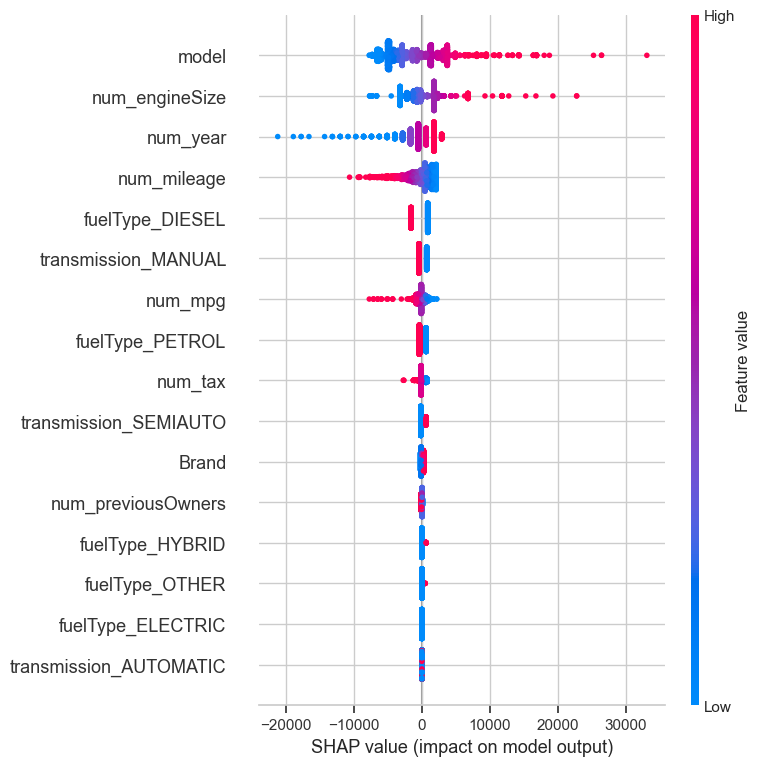

In [25]:
X_shap = X_full_final.copy()
X_shap = X_shap.astype(float)  # converts bool to 0/1 and ensures consistent dtype

apply_shap(lasso_final, X_shap, "Lasso Regression")

## 7. Elastic Net Regression (L1 + L2)

### 7.1. Model Introduction

Elastic Net combines L1 and L2 penalties, balancing the strengths of both Ridge and Lasso. This blended approach is particularly effective when predictors are correlated, as the L2 component stabilizes grouped variables while the L1 component retains the ability to remove uninformative ones. Elastic Net therefore avoids common pitfalls: pure Lasso may select features inconsistently under correlation, while pure Ridge cannot produce sparsity.

By tuning both penalties jointly, Elastic Net provides a flexible compromise that often yields stronger generalization than either method alone.

### 7.2. Hyperparameter Search (K-Fold)

In [26]:
valid_transmissions = ["MANUAL", "AUTOMATIC", "SEMIAUTO"]
valid_fueltypes    = ["PETROL", "DIESEL", "HYBRID"]

# KFold config
N_SPLITS = 8
RANDOM_STATE = 42

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

elastic_param_distributions = {
    "alpha": np.logspace(-5, 1, 40),
    "l1_ratio": np.linspace(0.1, 0.9, 9)
}

N_RANDOM_CONFIGS_EN = 60

elastic_sampler = ParameterSampler(
    elastic_param_distributions,
    n_iter=N_RANDOM_CONFIGS_EN,
    random_state=RANDOM_STATE
)

elastic_search_results = []

elastic_best_rmse = np.inf
elastic_best_config_rmse = None

elastic_best_mae = np.inf
elastic_best_config_mae = None

elastic_best_combo = np.inf
elastic_best_config_combo = None

elastic_log_path = "elasticnet_random_search_log.txt"

with open(elastic_log_path, "w", encoding="utf-8") as log_file:

    def log_en(msg: str):
        log_file.write(datetime.now().strftime("[%Y-%m-%d %H:%M:%S] ") + msg + "\n")
        log_file.flush()

    log_en("# =============================")
    log_en("# START OF RANDOM SEARCH ElasticNet")
    log_en("# =============================")
    log_en(f"N_SPLITS = {N_SPLITS}, N_RANDOM_CONFIGS = {N_RANDOM_CONFIGS_EN}")
    log_en(f"param_distributions = {elastic_param_distributions}")

    for config_id, params in enumerate(elastic_sampler, start=1):
        log_en("")
        log_en(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS_EN} ########")
        log_en(f"Parameters: {params}")

        fold_rmses_val = []
        fold_maes_val  = []
        fold_r2s_val   = []
        fold_bias_val  = []

        fold_rmses_tr = []
        fold_maes_tr  = []
        fold_r2s_tr   = []
        fold_bias_tr  = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            log_en("")
            log_en(f"[CONFIG {config_id}] ==== FOLD {fold}/{N_SPLITS} ====")

            X_train = X.iloc[train_idx].copy()
            X_val   = X.iloc[val_idx].copy()
            y_train = y.iloc[train_idx].copy()
            y_val   = y.iloc[val_idx].copy()

            # numeric preprocessing
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            tax_state = fit_tax_imputer(X_train, tax_col="tax", do_abs=True)
            X_train = transform_tax_imputer(X_train, state=tax_state)
            X_val   = transform_tax_imputer(X_val,   state=tax_state)

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            owners_state = fit_previous_owners_imputer(
                X_train, owners_col="previousOwners", year_col="year", mileage_col="mileage"
            )
            X_train = transform_previous_owners_imputer(X_train, state=owners_state)
            X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

            # resolvers
            brand_state = fit_ambiguous_brand_resolver(
                train_df=X_train, valid_brands=valid_brands,
                brand_col="Brand", model_col="model", year_col="year"
            )
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

            model_state = fit_invalid_model_resolver(
                train_df=X_train, valid_models_by_brand=valid_models_by_brand,
                brand_col="Brand", model_col="model", year_col="year",
                fuel_col="fuelType", mpg_col="mpg"
            )
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val,   _, _ = transform_invalid_models(X_val,   model_state)

            transm_state = fit_transmission_resolver(
                train_df=X_train, valid_transmissions=valid_transmissions,
                transm_col="transmission", brand_col="Brand",
                model_col="model", fuel_col="fuelType"
            )
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

            fuel_state = fit_fueltype_resolver(
                train_df=X_train, valid_fueltypes=valid_fueltypes,
                fuel_col="fuelType", brand_col="Brand",
                model_col="model", transm_col="transmission"
            )
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)

            # encoding
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # scaling
            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train[numeric_features])
            X_val_num   = scaler.transform(X_val[numeric_features])

            X_train_num_df = pd.DataFrame(
                X_train_num,
                index=X_train.index,
                columns=[f"num_{col}" for col in numeric_features]
            )
            X_val_num_df = pd.DataFrame(
                X_val_num,
                index=X_val.index,
                columns=[f"num_{col}" for col in numeric_features]
            )

            X_train_final = pd.concat([X_train_num_df, X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val_num_df,   X_val_cat],   axis=1)

            # model
            en = ElasticNet(
                alpha=params["alpha"],
                l1_ratio=params["l1_ratio"],
                fit_intercept=True,
                max_iter=10000
            )

            log_en(f"[C{config_id}|F{fold}] Training ElasticNet...")
            en.fit(X_train_final, y_train)

            y_pred_train = en.predict(X_train_final)
            y_pred_val   = en.predict(X_val_final)

            mse_val  = mean_squared_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mse_val)
            mae_val  = mean_absolute_error(y_val, y_pred_val)
            r2_val   = r2_score(y_val, y_pred_val)
            bias_val = float(np.mean(y_pred_val - y_val))

            mse_tr  = mean_squared_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mse_tr)
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            r2_tr   = r2_score(y_train, y_pred_train)
            bias_tr = float(np.mean(y_pred_train - y_train))

            log_en(f"[C{config_id}|F{fold}] TRAIN -> RMSE: {rmse_tr:.2f} | MAE: {mae_tr:.2f} | R2: {r2_tr:.4f} | Bias(pred-true): {bias_tr:.2f}")
            log_en(f"[C{config_id}|F{fold}] VAL   -> RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f} | R2: {r2_val:.4f} | Bias(pred-true): {bias_val:.2f}")

            fold_rmses_tr.append(rmse_tr)
            fold_maes_tr.append(mae_tr)
            fold_r2s_tr.append(r2_tr)
            fold_bias_tr.append(bias_tr)

            fold_rmses_val.append(rmse_val)
            fold_maes_val.append(mae_val)
            fold_r2s_val.append(r2_val)
            fold_bias_val.append(bias_val)

        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_rmse_tr = np.mean(fold_rmses_tr)
        mean_mae_tr  = np.mean(fold_maes_tr)
        mean_r2_tr   = np.mean(fold_r2s_tr)
        mean_bias_tr = np.mean(fold_bias_tr)

        combo_score = 0.5 * mean_rmse_val + 0.5 * mean_mae_val

        log_en(f"Config {config_id} - Avg TRAIN RMSE: {mean_rmse_tr:.2f} | MAE: {mean_mae_tr:.2f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.2f}")
        log_en(f"Config {config_id} - Avg VAL   RMSE: {mean_rmse_val:.2f} | MAE: {mean_mae_val:.2f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.2f}")
        log_en(f"Config {config_id} - Combined score (0.5*RMSE + 0.5*MAE) [VAL]: {combo_score:.2f}")

        elastic_search_results.append({
            "config_id": config_id,
            **params,
            "rmse_train_mean": mean_rmse_tr,
            "mae_train_mean": mean_mae_tr,
            "r2_train_mean": mean_r2_tr,
            "bias_train_mean": mean_bias_tr,
            "rmse_mean": mean_rmse_val,
            "mae_mean": mean_mae_val,
            "r2_mean": mean_r2_val,
            "bias_mean": mean_bias_val,
            "combo_score": combo_score,
        })

        if mean_rmse_val < elastic_best_rmse:
            elastic_best_rmse = mean_rmse_val
            elastic_best_config_rmse = {**params}
            log_en(f"[NEW BEST RMSE] Config {config_id} with avg RMSE (VAL) = {elastic_best_rmse:.2f}")

        if mean_mae_val < elastic_best_mae:
            elastic_best_mae = mean_mae_val
            elastic_best_config_mae = {**params}
            log_en(f"[NEW BEST MAE] Config {config_id} with avg MAE (VAL) = {elastic_best_mae:.2f}")

        if combo_score < elastic_best_combo:
            elastic_best_combo = combo_score
            elastic_best_config_combo = {**params}
            log_en(f"[NEW BEST COMBINED] Config {config_id} with score = {elastic_best_combo:.2f}")

    log_en("")
    log_en("# =============================")
    log_en("# END OF RANDOM SEARCH ElasticNet")
    log_en("# =============================")
    log_en(f"Best configuration (min RMSE VAL): {elastic_best_config_rmse}")
    log_en(f"Best average RMSE (VAL): {elastic_best_rmse:.2f}")
    log_en(f"Best configuration (min MAE VAL): {elastic_best_config_mae}")
    log_en(f"Best average MAE  (VAL): {elastic_best_mae:.2f}")
    log_en(f"Best configuration (combined score VAL): {elastic_best_config_combo}")
    log_en(f"Best combined score (VAL): {elastic_best_combo:.2f}")

elastic_results_df = pd.DataFrame(elastic_search_results)
elastic_results_df_sorted = elastic_results_df.sort_values(by="mae_mean", ascending=True)

display(elastic_results_df_sorted.head(10))

print("\nBest configuration found (min RMSE VAL):")
print(elastic_best_config_rmse)
print("Best average RMSE (VAL):", elastic_best_rmse)

print("\nBest configuration found (min MAE VAL):")
print(elastic_best_config_mae)
print("Best average MAE (VAL):", elastic_best_mae)

print("\nBest configuration found (min 0.5*RMSE + 0.5*MAE):")
print(elastic_best_config_combo)
print("Best combined score (VAL):", elastic_best_combo)

elastic_results_df_sorted.to_csv("elasticnet_random_search_results.csv", index=False)
print(f"\nDetailed logs in: {elastic_log_path}")

/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.726e+11, tolerance: 6.343e+08
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.679e+11, tolerance: 6.312e+08
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing reg

,config_id,l1_ratio,alpha,rmse_train_mean,mae_train_mean,r2_train_mean,bias_train_mean,rmse_mean,mae_mean,r2_mean,bias_mean,combo_score
51,52,0.4,0.100000,4176.599778,2631.641327,0.816002,-7.442515e-13,4203.499949,2638.322763,0.813561,-0.038431,3420.911356
30,31,0.7,0.289427,4189.783667,2631.456774,0.814838,2.262599e-13,4217.253710,2638.367995,0.812338,-0.030830,3427.810853
8,9,0.6,0.142510,4175.279557,2631.826961,0.816118,1.012591e-13,4202.113162,2638.489271,0.813684,-0.039222,3420.301217
50,51,0.8,0.587802,4206.903564,2633.864754,0.813322,-1.061719e-12,4234.959451,2640.997978,0.810757,-0.021623,3437.978714
42,43,0.9,1.193777,4208.248188,2634.151573,0.813203,-6.575958e-13,4236.344141,2641.301746,0.810634,-0.021150,3438.822944
25,26,0.5,0.049239,4163.014690,2636.699046,0.817197,-5.880946e-13,4189.064532,2643.106483,0.814841,-0.045596,3416.085508
52,53,0.3,0.034551,4162.880095,2636.814411,0.817209,4.846608e-14,4188.918510,2643.217583,0.814854,-0.045640,3416.068047
12,13,0.4,0.034551,4161.870660,2637.772609,0.817297,-2.817923e-13,4187.819313,2644.149480,0.814952,-0.045890,3415.984396
21,22,0.7,0.049239,4160.304383,2639.692611,0.817435,-5.267160e-13,4186.096376,2646.045068,0.815104,-0.046012,3416.070722
45,46,0.8,0.070170,4160.130428,2639.954175,0.817450,5.362821e-14,4185.903255,2646.303227,0.815122,-0.046001,3416.103241



Best configuration found (min RMSE VAL):
{'l1_ratio': np.float64(0.8), 'alpha': np.float64(0.001)}
Best average RMSE (VAL): 4183.247554118707

Best configuration found (min MAE VAL):
{'l1_ratio': np.float64(0.4), 'alpha': np.float64(0.1)}
Best average MAE (VAL): 2638.322763480441

Best configuration found (min 0.5*RMSE + 0.5*MAE):
{'l1_ratio': np.float64(0.4), 'alpha': np.float64(0.03455107294592222)}
Best combined score (VAL): 3415.9843964470983

Detailed logs in: elasticnet_random_search_log.txt


### 7.3. Final Model and Kaggle Predictions

In [27]:
# Choose final hyperparameters
final_config_en = elastic_best_config_rmse
#final_config_en = {
#    "alpha": elastic_best_config_rmse["alpha"],
#    "l1_ratio": elastic_best_config_rmse["l1_ratio"]
#}
print("Final ElasticNet config used for train:", final_config_en)

print("Preparing final ElasticNet Regression training...")

# 1) PREPARE FULL TRAIN FEATURES
X_full = X.copy()
y_full = y.copy()

# a) STRING NORMALIZATION
cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]

for col in cols_to_normalize:
    if col in X_full.columns:
        X_full[col] = X_full[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

high_card_features = ["Brand", "model"] 
low_card_features  = [c for c in categorical_features if c not in high_card_features]

# 2) NUMERIC PRE PROCESSING - FULL TRAIN
year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, state=year_state)

mileage_state = fit_mileage_imputer(X_full, mileage_col="mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, state=mileage_state)

engine_state = fit_engine_size_imputer(X_full, engine_col="engineSize")
X_full = transform_engine_size_imputer(X_full, state=engine_state)

tax_state = fit_tax_imputer(X_full, tax_col="tax", do_abs=True)
X_full = transform_tax_imputer(X_full, state=tax_state)

mpg_state = fit_mpg_imputer(X_full, mpg_col="mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, state=mpg_state)

# paint_state = fit_paint_quality_imputer(X_full, paint_col="paintQuality%")
# X_full = transform_paint_quality_imputer(X_full, state=paint_state)

owners_state = fit_previous_owners_imputer(
    X_full, owners_col="previousOwners", year_col="year", mileage_col="mileage"
)
X_full = transform_previous_owners_imputer(X_full, state=owners_state)

# 3) CATEGORICAL RESOLVERS - FULL TRAIN
brand_state = fit_ambiguous_brand_resolver(
    train_df=X_full, valid_brands=valid_brands, 
    brand_col="Brand", model_col="model", year_col="year"
)
X_full, _, brand_still_invalid_full = transform_ambiguous_brands(X_full, brand_state)
print(f"Train full - Invalid Brands remaining: {len(brand_still_invalid_full)}")

model_state = fit_invalid_model_resolver(
    train_df=X_full, valid_models_by_brand=valid_models_by_brand,
    brand_col="Brand", model_col="model", year_col="year", 
    fuel_col="fuelType", mpg_col="mpg"
)
X_full, _, model_still_invalid_full = transform_invalid_models(X_full, model_state)
print(f"Train full - Invalid Models remaining: {len(model_still_invalid_full)}")

transm_state = fit_transmission_resolver(
    train_df=X_full, valid_transmissions=valid_transmissions,
    transm_col="transmission", brand_col="Brand", 
    model_col="model", fuel_col="fuelType"
)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

fuel_state = fit_fueltype_resolver(
    train_df=X_full, valid_fueltypes=valid_fueltypes,
    fuel_col="fuelType", brand_col="Brand", 
    model_col="model", transm_col="transmission"
)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)

# 4) CATEGORICAL ENCODING - FULL TRAIN
te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full)
X_full_high = te.transform(X_full[high_card_features])

ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)
print("X_full_cat shape:", X_full_cat.shape)

# 5) NUMERIC SCALING - FULL TRAIN
scaler = StandardScaler()
X_full_num = scaler.fit_transform(X_full[numeric_features])

X_full_num_df = pd.DataFrame(
    X_full_num,
    index=X_full.index,
    columns=[f"num_{col}" for col in numeric_features]
)
print("X_full_num_df shape:", X_full_num_df.shape)

# 6) FINAL MATRIX - FULL TRAIN
X_full_final = pd.concat([X_full_num_df, X_full_cat], axis=1)
print("X_full_final shape:", X_full_final.shape)

# 7) TRAIN FINAL ELASTIC NET MODEL
en_final = ElasticNet(
    alpha=final_config_en["alpha"],
    l1_ratio=final_config_en["l1_ratio"],
    fit_intercept=True,
    max_iter=10000
)

print("Training final ElasticNet Regression model on full data...")
en_final.fit(X_full_final, y_full)
print("Done.")

# 8) PREPARE TEST FEATURES
test_df = pd.read_csv("../../project_data/test.csv")

for col in cols_to_normalize:
    if col in test_df.columns:
        test_df[col] = test_df[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

X_test = test_df[numeric_features + categorical_features].copy()

# NUMERIC PREPROCESSING - TEST
X_test = transform_year_with_model_median(X_test, state=year_state)
X_test = transform_mileage_imputer(X_test, state=mileage_state)
X_test = transform_engine_size_imputer(X_test, state=engine_state)
X_test = transform_tax_imputer(X_test, state=tax_state)
X_test = transform_mpg_imputer(X_test, state=mpg_state)
# X_test = transform_paint_quality_imputer(X_test, state=paint_state)
X_test = transform_previous_owners_imputer(X_test, state=owners_state)

# CATEGORICAL RESOLVERS - TEST
X_test, _, _ = transform_ambiguous_brands(X_test, brand_state)
X_test, _, _ = transform_invalid_models(X_test, model_state)
X_test, _, _ = transform_transmission_resolver(X_test, transm_state)
X_test, _, _ = transform_fueltype_resolver(X_test, fuel_state)

# ENCODING - TEST
X_test_high = te.transform(X_test[high_card_features])
X_test_low  = ohe.transform(X_test[low_card_features])
X_test_cat  = pd.concat([X_test_high, X_test_low], axis=1)

# SCALING - TEST
X_test_num = scaler.transform(X_test[numeric_features])
X_test_num_df = pd.DataFrame(
    X_test_num,
    index=X_test.index,
    columns=[f"num_{col}" for col in numeric_features]
)

# FINAL MATRIX & PREDICTION
X_test_final = pd.concat([X_test_num_df, X_test_cat], axis=1)
X_test_final = X_test_final[X_full_final.columns]

print("X_test_final shape:", X_test_final.shape)

y_test_pred = en_final.predict(X_test_final)

print("Predictions summary (float):")
print(pd.Series(y_test_pred).describe())

y_test_pred_round = np.round(y_test_pred).astype(int)

submission = pd.DataFrame({
    "carID": test_df["carID"].astype(int),
    "price": y_test_pred  
})

sub_name = (
    f"elasticnet_regression_final_submission_a{final_config_en['alpha']:.4f}"
    f"_l1{final_config_en['l1_ratio']:.2f}.csv"
)
submission.to_csv(sub_name, index=False)
print(f"Submission file created: {sub_name}")

Final ElasticNet config used for train: {'l1_ratio': np.float64(0.8), 'alpha': np.float64(0.001)}
Preparing final ElasticNet Regression training...
Train full - Invalid Brands remaining: 0
Train full - Invalid Models remaining: 1
X_full_cat shape: (75973, 10)
X_full_num_df shape: (75973, 6)
X_full_final shape: (75973, 16)
Training final ElasticNet Regression model on full data...
Done.
X_test_final shape: (32567, 16)
Predictions summary (float):
count    32567.000000
mean     16897.942089
std       8754.142220
min     -19431.626732
25%      10848.054749
50%      15468.109488
75%      22288.758151
max      95042.488548
dtype: float64
Submission file created: elasticnet_regression_final_submission_a0.0010_l10.80.csv


### 7.4. Diagnostic Visualizations

#### 7.4.1. Predicted vs true

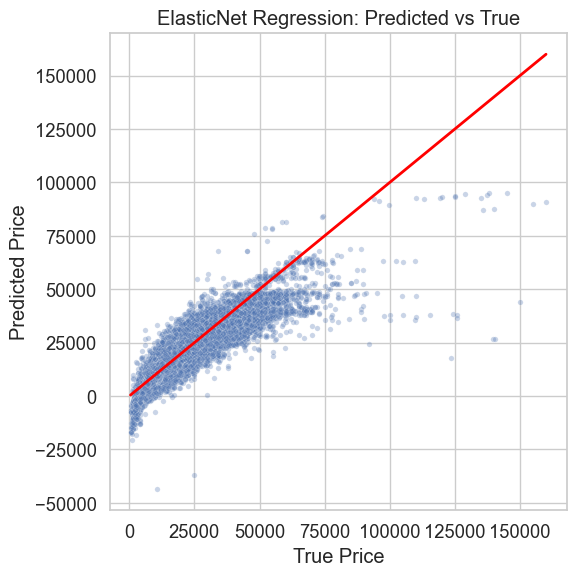

In [28]:
plot_pred_vs_true(en_final, "ElasticNet Regression")

#### 7.4.2. Residuals vs Predicted (heteroscedasticity check)

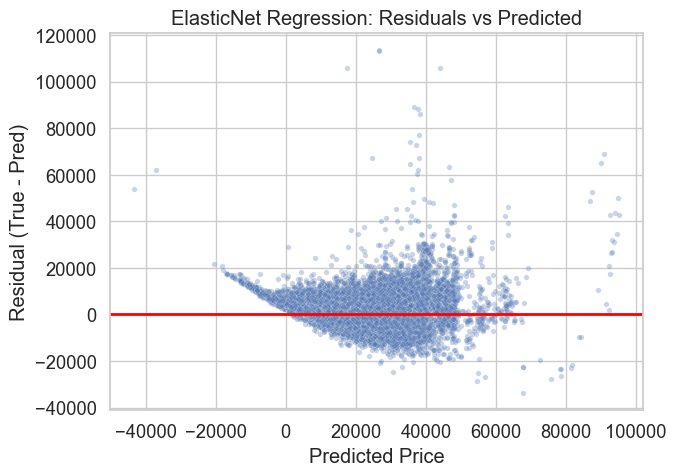

In [29]:
plot_residuals(en_final, "ElasticNet Regression")

#### 7.4.3. Residual distribution

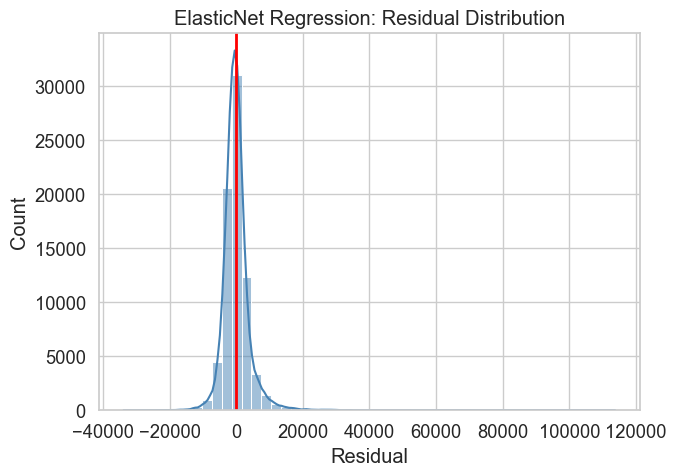

In [30]:
plot_residual_distribution(en_final, "ElasticNet Regression")

#### 7.4.4. Permutation Importance

/var/folders/ts/9fy52qg56jz05nxpdkmswkzw0000gr/T/ipykernel_29804/2081930191.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=imp_df, palette="magma")


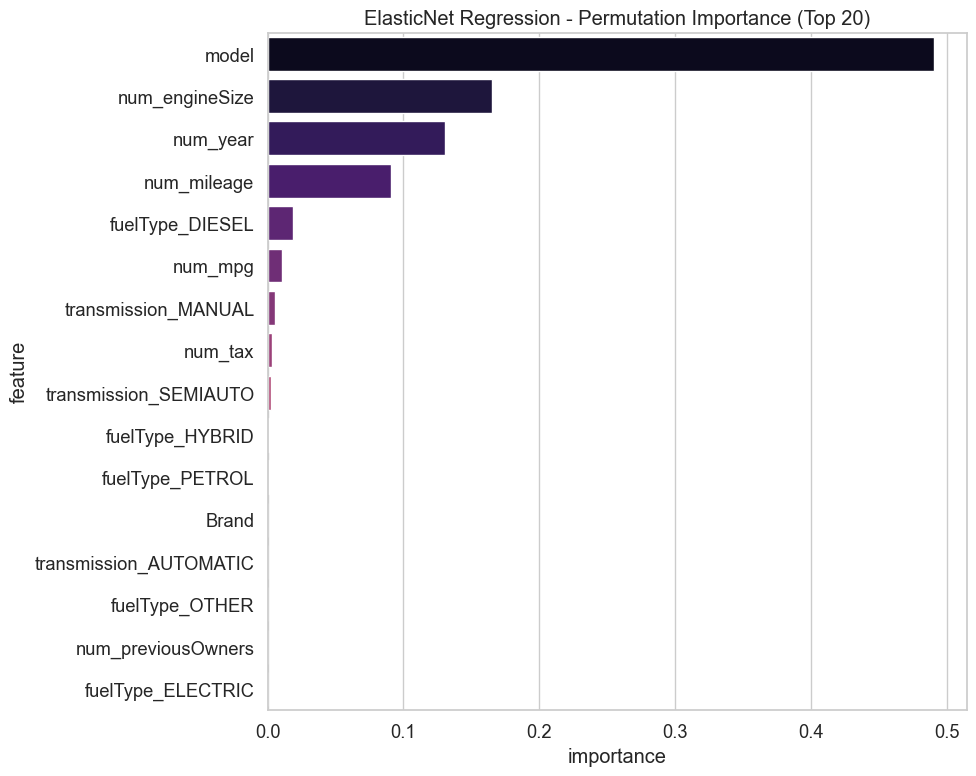

In [31]:
plot_permutation_importance(en_final, "ElasticNet Regression")

#### 7.4.5. SHAP


SHAP for ElasticNet Regression (sample size = 2000)


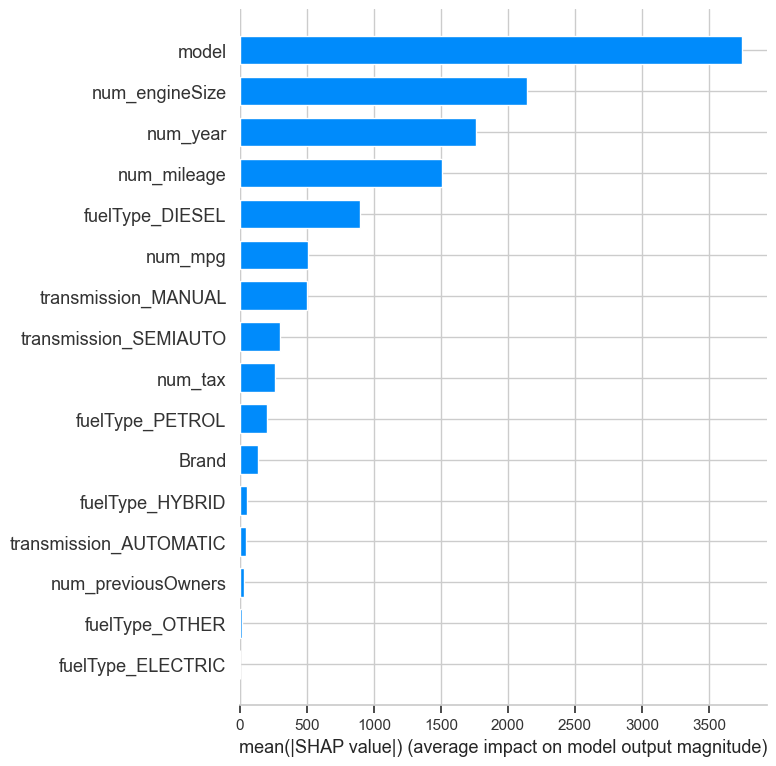

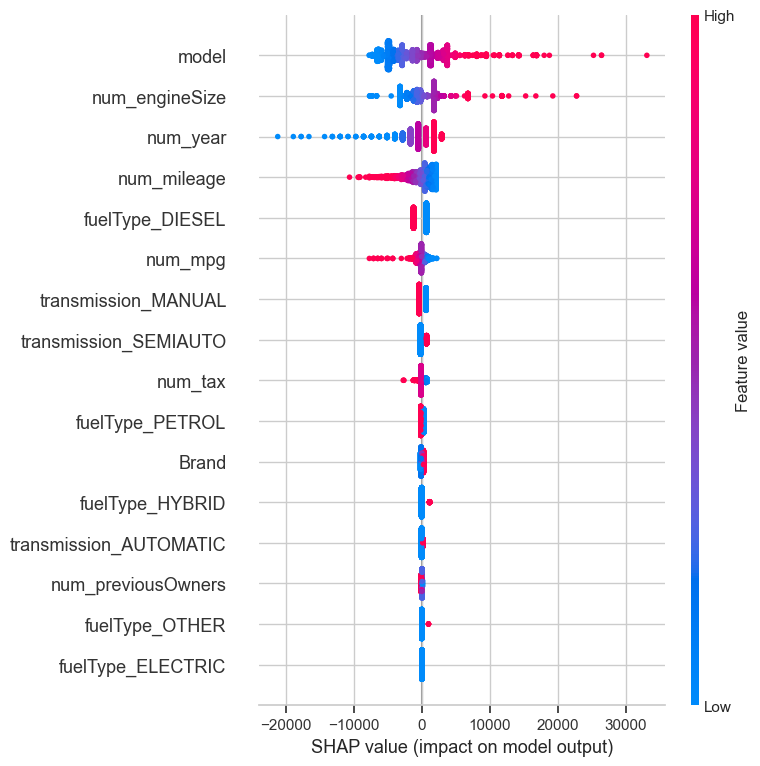

In [32]:
X_shap = X_full_final.copy()
X_shap = X_shap.astype(float)  # converts bool to 0/1 and ensures consistent dtype

apply_shap(en_final, X_shap, "ElasticNet Regression")

## 8. Comparative Analysis

### 8.1. Performance Comparison Table

In [33]:
# 1) Helper for the baseline (pure KFold, no random search) 

def summarize_baseline_linreg(
    model_name: str,
    rmse_tr_list, mae_tr_list, r2_tr_list, bias_tr_list,
    rmse_val_list, mae_val_list, r2_val_list, bias_val_list
) -> pd.DataFrame:
    """Summarize baseline Linear Regression CV metrics (train + val means)."""
    rmse_tr_arr  = np.array(rmse_tr_list, dtype=float)
    mae_tr_arr   = np.array(mae_tr_list,  dtype=float)
    r2_tr_arr    = np.array(r2_tr_list,   dtype=float)
    bias_tr_arr  = np.array(bias_tr_list, dtype=float)

    rmse_val_arr = np.array(rmse_val_list, dtype=float)
    mae_val_arr  = np.array(mae_val_list,  dtype=float)
    r2_val_arr   = np.array(r2_val_list,   dtype=float)
    bias_val_arr = np.array(bias_val_list, dtype=float)

    row = {
        "Model": model_name,
        "RMSE_train_mean": rmse_tr_arr.mean(),
        "MAE_train_mean":  mae_tr_arr.mean(),
        "R2_train_mean":   r2_tr_arr.mean(),
        "Bias_train_mean": bias_tr_arr.mean(),
        "RMSE_val_mean":   rmse_val_arr.mean(),
        "MAE_val_mean":    mae_val_arr.mean(),
        "R2_val_mean":     r2_val_arr.mean(),
        "Bias_val_mean":   bias_val_arr.mean(),
    }
    return pd.DataFrame([row])


# 2) Helper for models tuned via random search 

def summarize_from_search_df(
    model_name: str,
    results_df: pd.DataFrame,
    best_config: dict,
    config_cols=("alpha",)
) -> pd.DataFrame:
    """
    Extract the row in results_df corresponding to best_config and
    return metrics in the same format as the baseline summary.

    config_cols: tuple of hyperparameter columns that identify the config.
    """
    mask = np.ones(len(results_df), dtype=bool)
    for col in config_cols:
        if col in results_df.columns and col in best_config:
            mask &= (results_df[col] == best_config[col])
    best_row = results_df.loc[mask].sort_values("mae_mean").iloc[0]

    row = {
        "Model": model_name,
        "RMSE_train_mean": best_row["rmse_train_mean"],
        "MAE_train_mean":  best_row["mae_train_mean"],
        "R2_train_mean":   best_row["r2_train_mean"],
        "Bias_train_mean": best_row["bias_train_mean"],
        "RMSE_val_mean":   best_row["rmse_mean"],
        "MAE_val_mean":    best_row["mae_mean"],
        "R2_val_mean":     best_row["r2_mean"],
        "Bias_val_mean":   best_row["bias_mean"],
    }
    return pd.DataFrame([row])


# 3) Build the comparison table for all four models 

# 3.1 Baseline Linear Regression (uses CV lists)
df_lin = summarize_baseline_linreg(
    model_name="Linear Regression (OLS)",
    rmse_tr_list=cv_fold_rmses_train,
    mae_tr_list=cv_fold_maes_train,
    r2_tr_list=cv_fold_r2s_train,
    bias_tr_list=cv_fold_bias_train,
    rmse_val_list=cv_fold_rmses_val,
    mae_val_list=cv_fold_maes_val,
    r2_val_list=cv_fold_r2s_val,
    bias_val_list=cv_fold_bias_val,
)

# 3.2 Ridge 
df_ridge = summarize_from_search_df(
    model_name="Ridge Regression",
    results_df=ridge_results_df, 
    best_config=ridge_best_config_rmse,
    config_cols=("alpha",)
)

# 3.3 Lasso 
df_lasso = summarize_from_search_df(
    model_name="Lasso Regression",
    results_df=lasso_results_df, 
    best_config=lasso_best_config_rmse, 
    config_cols=("alpha",)
)

# 3.4 Elastic Net 
df_elastic = summarize_from_search_df(
    model_name="Elastic Net Regression",
    results_df=elastic_results_df,
    best_config=elastic_best_config_rmse, 
    config_cols=("alpha", "l1_ratio")
)

# 3.5 Final comparison table
df_linear_models_perf = pd.concat(
    [df_lin, df_ridge, df_lasso, df_elastic],
    ignore_index=True
)

# Sort by validation MAE (best at top)
df_linear_models_perf = df_linear_models_perf.sort_values(
    "MAE_val_mean"
).reset_index(drop=True)

display(
    df_linear_models_perf.style.format(
        {
            "RMSE_train_mean": "{:.2f}",
            "MAE_train_mean":  "{:.2f}",
            "R2_train_mean":   "{:.4f}",
            "Bias_train_mean": "{:.2f}",
            "RMSE_val_mean":   "{:.2f}",
            "MAE_val_mean":    "{:.2f}",
            "R2_val_mean":     "{:.4f}",
            "Bias_val_mean":   "{:.2f}",
        }
    )
)


,Model,RMSE_train_mean,MAE_train_mean,R2_train_mean,Bias_train_mean,RMSE_val_mean,MAE_val_mean,R2_val_mean,Bias_val_mean
0,Elastic Net Regression,4157.78,2647.05,0.8177,-0.00,4183.25,2653.35,0.8154,-0.06
1,Ridge Regression,4157.77,2647.17,0.8177,-0.00,4183.26,2653.48,0.8154,-0.06
2,Lasso Regression,4157.77,2647.21,0.8177,0.00,4183.26,2653.52,0.8154,-0.06
3,Linear Regression (OLS),4157.77,2647.23,0.8177,-0.00,4183.29,2653.57,0.8154,-0.05


The four linear models achieved very similar performances, with all metrics converging to the same range across folds.

This indicates that, under our preprocessing and feature space, adding regularization (Ridge, Lasso, ElasticNet) did not materially change the bias. In practice, this suggests that multicollinearity is not severe enough to penalize OLS, and the regularization paths of the penalized models shrink coefficients only minimally. 

The similarity in results reinforces that the underlying linear signal is already well captured and that further gains likely depend on nonlinear models or feature engineering rather than additional linear regularization.

### 8.2. Coefficient Comparison

<Figure size 1200x700 with 0 Axes>

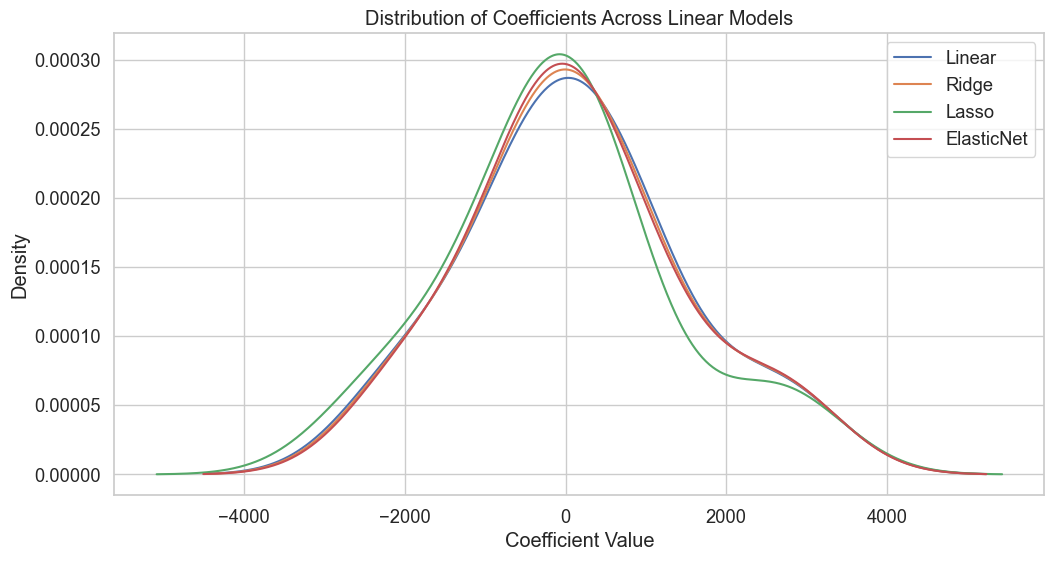

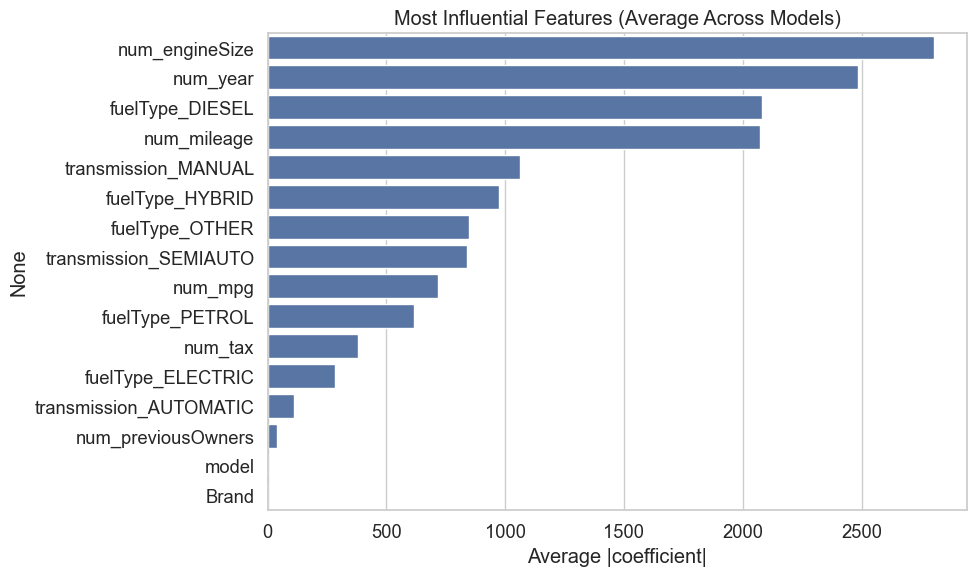

In [34]:
models = [linreg_final, ridge_final, lasso_final, en_final]
model_names = ["Linear", "Ridge", "Lasso", "ElasticNet"] # run this after running Ridge, Lasso and ElasticNet notebooks for comparison!

plot_coefficients(models, model_names)

The coefficient distributions show that all linear variants learn almost identical parameter structures, with Ridge and ElasticNet introducing only mild shrinkage and Lasso producing slightly heavier tails due to its selective penalization. This reinforces the earlier conclusion that the underlying linear signal is stable across models and only weakly affected by regularization.

When averaging absolute coefficients, the ranking of influential features is highly consistent: `engineSize`, `year`, `mileage`, and `fuelType` remain dominant, regardless of the specific linear formulation. Categorical encodings like `transmission` also show meaningful but smaller contributions, while `Brand` and `model` provide minimal linear predictive power under the current preprocessing. Together, these results indicate that the linear structure of the problem is well-defined and robust, with slight model differences arising mainly from regularization strength rather than fundamentally different learned relationships.

## 9. Closing summary

This notebook examined four linear and regularized models within a unified preprocessing and cross-validation framework.

Ordinary Least Squares established the interpretability baseline, revealing the linear structure of the data and defining the minimum performance threshold. Ridge addressed coefficient instability by shrinking correlated predictors, Lasso explored sparsity and automatic feature selection, and ElasticNet provided a balanced middle ground capable of both stabilization and variable reduction.

The insights gained here set the stage for evaluating more expressive nonlinear models in subsequent notebooks and help justify whether added complexity yields meaningful improvements in predictive performance.